# Executive Brief

## Business Problem

Customer churn reduces recurring revenue and increases customer acquisition costs. This project builds an early-warning classification system that estimates which customers are most likely to churn, giving retention teams time to intervene with relevant service, loyalty, or engagement actions.

## Business Questions

- **Who** is most likely to churn, and how should customers be ranked for action?
- **What** profile, spend, engagement, service, and loyalty behaviors are associated with churn?
- **Where** are the highest-risk customer segments and commercial opportunities?
- **When** should the business intervene relative to a customer's recent activity?
- **Why** is a supervised tabular model appropriate for this decision-support problem?
- **How** can predicted risk be converted into targeted interventions and measured through incremental retention?

## Success Criteria

The model should prioritize churn recall and average precision alongside ROC-AUC, precision, and F1-score. Accuracy is reported for context but is not sufficient because churn is a minority class. Business success ultimately requires an intervention experiment that measures incremental retention, revenue protected, campaign cost, and customer experience.

## Architecture

```mermaid
flowchart LR
    A[Customer profile] --> C[Validate and merge]
    B[Customer behavior] --> C
    C --> D[Clean and engineer features]
    D --> E[Segment customers]
    D --> F[Preprocess and address imbalance]
    F --> G[Compare and tune classifiers]
    G --> H[Churn probability]
    H --> I[Retention prioritization]
    I --> J[Campaign measurement]
```

## Modeling Decision

The notebook compares Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM. LightGBM is the leading candidate because it handles mixed tabular data efficiently, captures nonlinear interactions, and supports useful feature-importance diagnostics. Logistic Regression remains the interpretable baseline, while the tree models test increasingly flexible alternatives.

The current reported tuned LightGBM results are validation ROC-AUC `0.7745`, average precision `0.5849`, churn recall `0.60`, and churn F1-score `0.5479`. These values are provisional because resampling and segmentation should be fitted inside each validation fold for a fully leakage-safe estimate.

---


# Customer Churn Prediction — ML Capstone

**Objective:** Build an end-to-end predictive system to identify customers at high risk of churning, using customer profile and behavioral data.

---
### Notebook Structure
1. Setup & Imports
2. Data Loading & Merging
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Customer Segmentation via Clustering
7. Preprocessing Pipeline
8. Handling Class Imbalance
9. Model Training & Comparison
10. Hyperparameter Tuning
11. Final Model Evaluation & Feature Importance
12. Test Predictions & Submission

## 1. Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score, f1_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline

# Misc
from scipy.stats import randint, uniform

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Retained': '#2196F3', 'Churned': '#F44336'}
SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Merging

In [ ]:
# Load raw files from the repository root. Keep raw data local and do not publish it without approval.
DATA_DIR = Path.cwd()
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

train_profile   = pd.read_csv(DATA_DIR / 'train_customer_profile.csv')
train_behavior  = pd.read_csv(DATA_DIR / 'train_customer_behavior.csv')
test_profile    = pd.read_csv(DATA_DIR / 'test_customer_profile.csv')
test_behavior   = pd.read_csv(DATA_DIR / 'test_customer_behavior.csv')

print(f'Train Profile  : {train_profile.shape}')
print(f'Train Behavior : {train_behavior.shape}')
print(f'Test  Profile  : {test_profile.shape}')
print(f'Test  Behavior : {test_behavior.shape}')

Train Profile  : (15000, 12)
Train Behavior : (15000, 14)
Test  Profile  : (5000, 11)
Test  Behavior : (5000, 14)


In [102]:
# Verify join key integrity before merging
assert train_profile['customer_id'].nunique() == len(train_profile), 'Duplicate customer_ids in train_profile'
assert train_behavior['customer_id'].nunique() == len(train_behavior), 'Duplicate customer_ids in train_behavior'

common_train = set(train_profile['customer_id']) & set(train_behavior['customer_id'])
print(f'Common train customer_ids: {len(common_train)} / {len(train_profile)}')

# Merge on customer_id (inner join — only rows present in both)
train = train_profile.merge(train_behavior, on='customer_id', how='inner')
test  = test_profile.merge(test_behavior,   on='customer_id', how='inner')

print(f'\nMerged Train : {train.shape}')
print(f'Merged Test  : {test.shape}')

Common train customer_ids: 15000 / 15000

Merged Train : (15000, 25)
Merged Test  : (5000, 24)


In [103]:
# Quick peek at merged train
train.head(3)

,customer_id,age,gender,region,income_tier,education_level,marital_status,tenure_months,contract_type,preferred_channel,loyalty_tier,churn,purchase_frequency,avg_order_value,total_spend_6m,recency_days,product_categories_used,returns_ratio,email_open_rate,app_sessions_per_month,support_tickets_6m,campaign_response_rate,last_promotion_used,customer_satisfaction_score,payment_method
0,CUST001662,50.0000,Male,NORTH,Mid,Graduate,Divorced,25,Monthly,In-store,Silver,0,14.0000,114.3200,1610.8400,162.0000,3,0.2156,NaN,NaN,0,0.4797,Discount,50.0000,Credit Card
1,CUST013618,34.0000,Male,Central,Low,Post-Graduate,Single,18,Monthly,Web,Silver,1,3.0000,100.6400,293.6200,86.0000,1,0.1751,0.6231,33.0000,7,0.1093,Cashback,NaN,Debit Card
2,CUST000447,NaN,F,North,Mid,Post-Graduate,Married,67,Annual,App,Bronze,0,7.0000,41.0800,260.0000,72.0000,6,0.1391,0.4749,23.0000,0,0.6950,Discount,67.5000,Credit Card


In [104]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  15000 non-null  object 
 1   age                          13750 non-null  float64
 2   gender                       15000 non-null  object 
 3   region                       15000 non-null  object 
 4   income_tier                  13578 non-null  object 
 5   education_level              13537 non-null  object 
 6   marital_status               15000 non-null  object 
 7   tenure_months                15000 non-null  int64  
 8   contract_type                15000 non-null  object 
 9   preferred_channel            15000 non-null  object 
 10  loyalty_tier                 12801 non-null  object 
 11  churn                        15000 non-null  int64  
 12  purchase_frequency           13493 non-null  float64
 13  avg_order_value 

## 3. Exploratory Data Analysis

### 3.1 Statistical Summary

In [105]:
# Statistical summary
print("=" * 60)
print("NUMERICAL FEATURES — DESCRIPTIVE STATISTICS")
print("=" * 60)
train.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])


NUMERICAL FEATURES — DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,13750.000000,42.314400,12.470764,18.000000,34.000000,42.000000,51.000000,75.000000
tenure_months,15000.000000,30.757000,20.862740,1.000000,15.000000,26.000000,42.000000,120.000000
churn,15000.000000,0.212533,0.409114,0.000000,0.000000,0.000000,0.000000,1.000000
purchase_frequency,13493.000000,13.852813,11.548643,1.000000,5.000000,11.000000,20.000000,42.000000
avg_order_value,15000.000000,170.038257,258.478722,10.000000,36.670000,100.050000,198.832500,6107.890000
total_spend_6m,15000.000000,1848.918636,2430.567786,10.220000,360.915000,1074.545000,2349.395000,20384.820000
recency_days,13827.000000,92.779923,60.230928,1.000000,42.000000,92.000000,144.000000,183.000000
product_categories_used,15000.000000,3.728067,2.227745,1.000000,2.000000,4.000000,5.000000,8.000000
returns_ratio,13281.000000,0.243543,0.179258,0.000000,0.099400,0.227100,0.361000,0.950000
email_open_rate,13505.000000,0.462003,0.290529,0.000000,0.231700,0.458300,0.682100,0.980000


**Observation:** The dataset is imbalanced (~21% churn). We will address this with SMOTE oversampling and class-weighted models.

In [106]:
# Categorical summary
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customer_id', 'churn_label']]
print("=" * 60)
print("CATEGORICAL FEATURES — UNIQUE VALUE COUNTS")
print("=" * 60)
for col in cat_cols:
    print(f"  {col:35s} → {train[col].nunique()} unique : {train[col].unique()[:6]}")


CATEGORICAL FEATURES — UNIQUE VALUE COUNTS
  gender                              → 9 unique : ['Male' 'F' 'MALE' 'male' 'Female' 'Non-binary']
  region                              → 17 unique : ['NORTH' 'Central' 'North' 'west' 'South ' 'central']
  income_tier                         → 3 unique : ['Mid' 'Low' 'High' nan]
  education_level                     → 4 unique : ['Graduate' 'Post-Graduate' 'High School' nan 'Doctorate']
  marital_status                      → 4 unique : ['Divorced' 'Single' 'Married' 'Widowed']
  contract_type                       → 6 unique : ['Monthly' 'Annual' 'Multi-year' 'multiyear' 'Multi year' 'multi-year']
  preferred_channel                   → 4 unique : ['In-store' 'Web' 'App' 'Phone']
  loyalty_tier                        → 4 unique : ['Silver' 'Bronze' 'Gold' nan 'Platinum']
  last_promotion_used                 → 4 unique : ['Discount' 'Cashback' nan 'Free Shipping' 'No Promotion']
  payment_method                      → 4 unique : ['Credit Ca

### 3.2 Missing Value Analysis

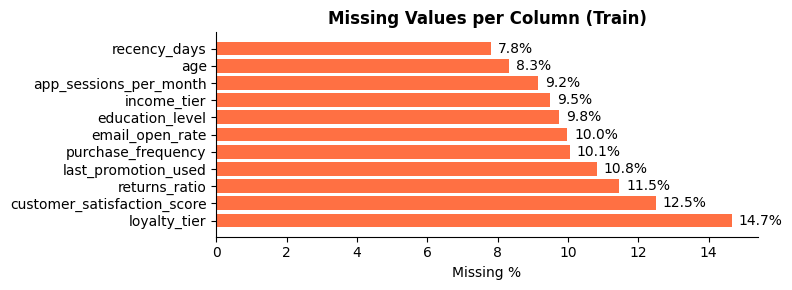

,Missing Count,Missing %
loyalty_tier,2199,14.6600
customer_satisfaction_score,1874,12.4900
returns_ratio,1719,11.4600
last_promotion_used,1623,10.8200
purchase_frequency,1507,10.0500
email_open_rate,1495,9.9700
education_level,1463,9.7500
income_tier,1422,9.4800
app_sessions_per_month,1373,9.1500
age,1250,8.3300


In [107]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#FF7043')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

display(missing_df)

### 3.3 Target Variable Summary

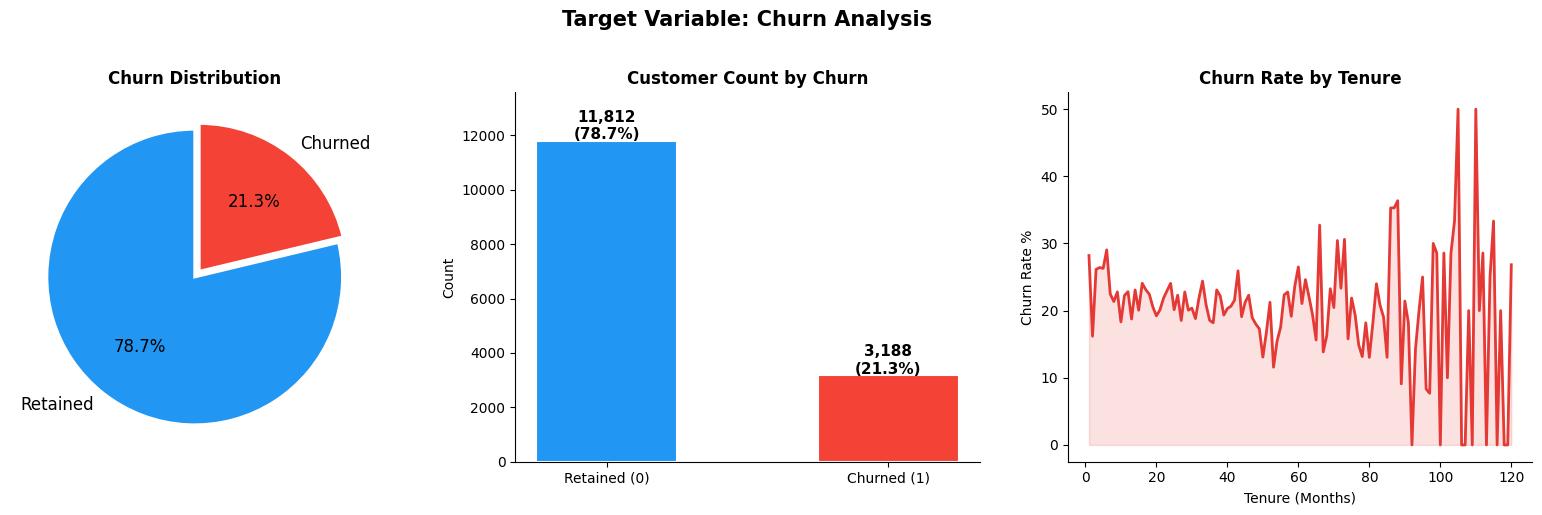


📊 Class Balance Summary:
   Retained: 11,812 (78.7%)
   Churned : 3,188 (21.3%)
   Imbalance Ratio: 3.71:1


In [108]:
churn_counts = train['churn'].value_counts()
churn_pct = train['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
axes[0].pie(churn_counts.values, labels=['Retained', 'Churned'],
            colors=[PALETTE['Retained'], PALETTE['Churned']],
            autopct='%1.1f%%', startangle=90, explode=[0, 0.05],
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontweight='bold')

# Bar chart
bars = axes[1].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
                    color=[PALETTE['Retained'], PALETTE['Churned']], 
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Customer Count by Churn', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(churn_counts.values) * 1.15)

# Cumulative churn by tenure
tenure_churn = train.groupby('tenure_months')['churn'].mean().reset_index()
axes[2].plot(tenure_churn['tenure_months'], tenure_churn['churn'] * 100,
             color='#E53935', linewidth=2)
axes[2].fill_between(tenure_churn['tenure_months'], tenure_churn['churn'] * 100,
                     alpha=0.15, color='#E53935')
axes[2].set_xlabel('Tenure (Months)')
axes[2].set_ylabel('Churn Rate %')
axes[2].set_title('Churn Rate by Tenure', fontweight='bold')

plt.suptitle('Target Variable: Churn Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Class Balance Summary:")
print(f"   Retained: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"   Churned : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")
print(f"   Imbalance Ratio: {churn_counts[0]/churn_counts[1]:.2f}:1")


### 3.4 Univariate Analysis - Numerical Features

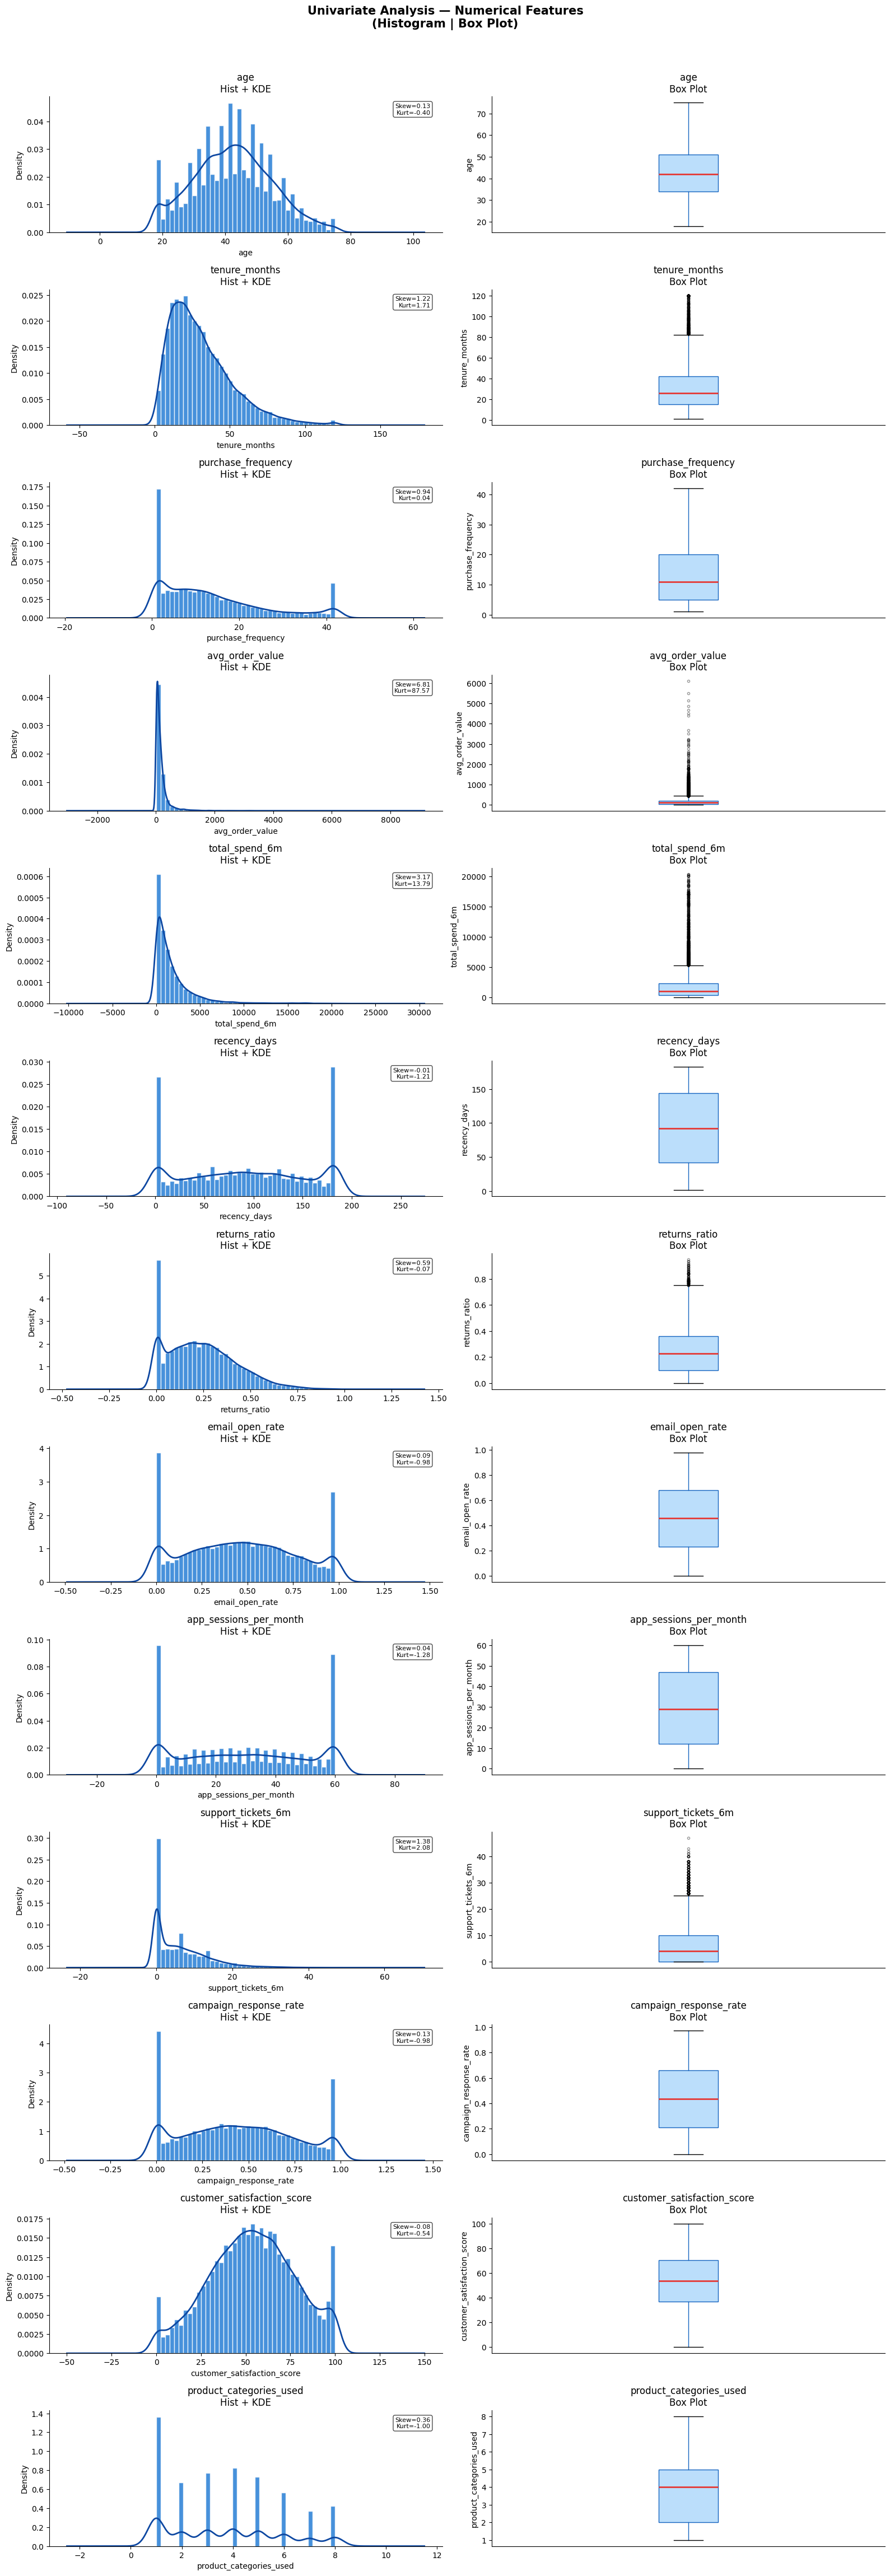

In [109]:
num_cols = ['age', 'tenure_months', 'purchase_frequency', 'avg_order_value',
            'total_spend_6m', 'recency_days', 'returns_ratio', 'email_open_rate',
            'app_sessions_per_month', 'support_tickets_6m', 'campaign_response_rate',
            'customer_satisfaction_score', 'product_categories_used']

n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(16, n * 3.5))
fig.suptitle('Univariate Analysis — Numerical Features\n(Histogram | Box Plot)',
             fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(num_cols):
    data = train[col].dropna()

    # Histogram + KDE
    axes[i, 0].hist(data, bins=40, color='#1976D2', edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=axes[i, 0], color='#0D47A1', linewidth=2)
    axes[i, 0].set_title(f'{col}\nHist + KDE')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')

    # Skew & Kurt annotation
    skew = data.skew()
    kurt = data.kurtosis()
    axes[i, 0].text(0.97, 0.95, f'Skew={skew:.2f}\nKurt={kurt:.2f}',
                    transform=axes[i, 0].transAxes, ha='right', va='top',
                    fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    # Box plot
    axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                       medianprops=dict(color='#E53935', linewidth=2),
                       whiskerprops=dict(color='#1565C0'),
                       flierprops=dict(marker='o', color='#E53935', alpha=0.4, markersize=3))
    axes[i, 1].set_title(f'{col}\nBox Plot')
    axes[i, 1].set_ylabel(col)
    axes[i, 1].set_xticks([])

plt.tight_layout()
plt.show()


#### Key Observations:

* **Near-Normal:** `Age` and `customer_satisfaction_score` are well-balanced and symmetric, though satisfaction is sharply truncated at the 0 and 100 boundaries.
* **Heavily Right-Skewed:** `tenure_months`, `purchase_frequency`, `avg_spend_value`, and `total_spend_amt` are heavily clustered near zero with long right tails and dense outliers. *Recommendation: Apply Log or Box-Cox transformation.*
* **Uniform with Boundary Spikes:** `days_since_last_purchase`, `email_open_rate`, and `campaign_response_rate` are flat across the middle but spike sharply at 0 and maximum limits, indicating highly polarized user behavior.
* **Discrete / Multimodal:** `product_categories_used` shows distinct, rigid integer spikes (comb pattern), and `avg_sessions_per_month` displays a block-like uniform distribution.

### 3.5 Univariate Analysis - Categorical Features

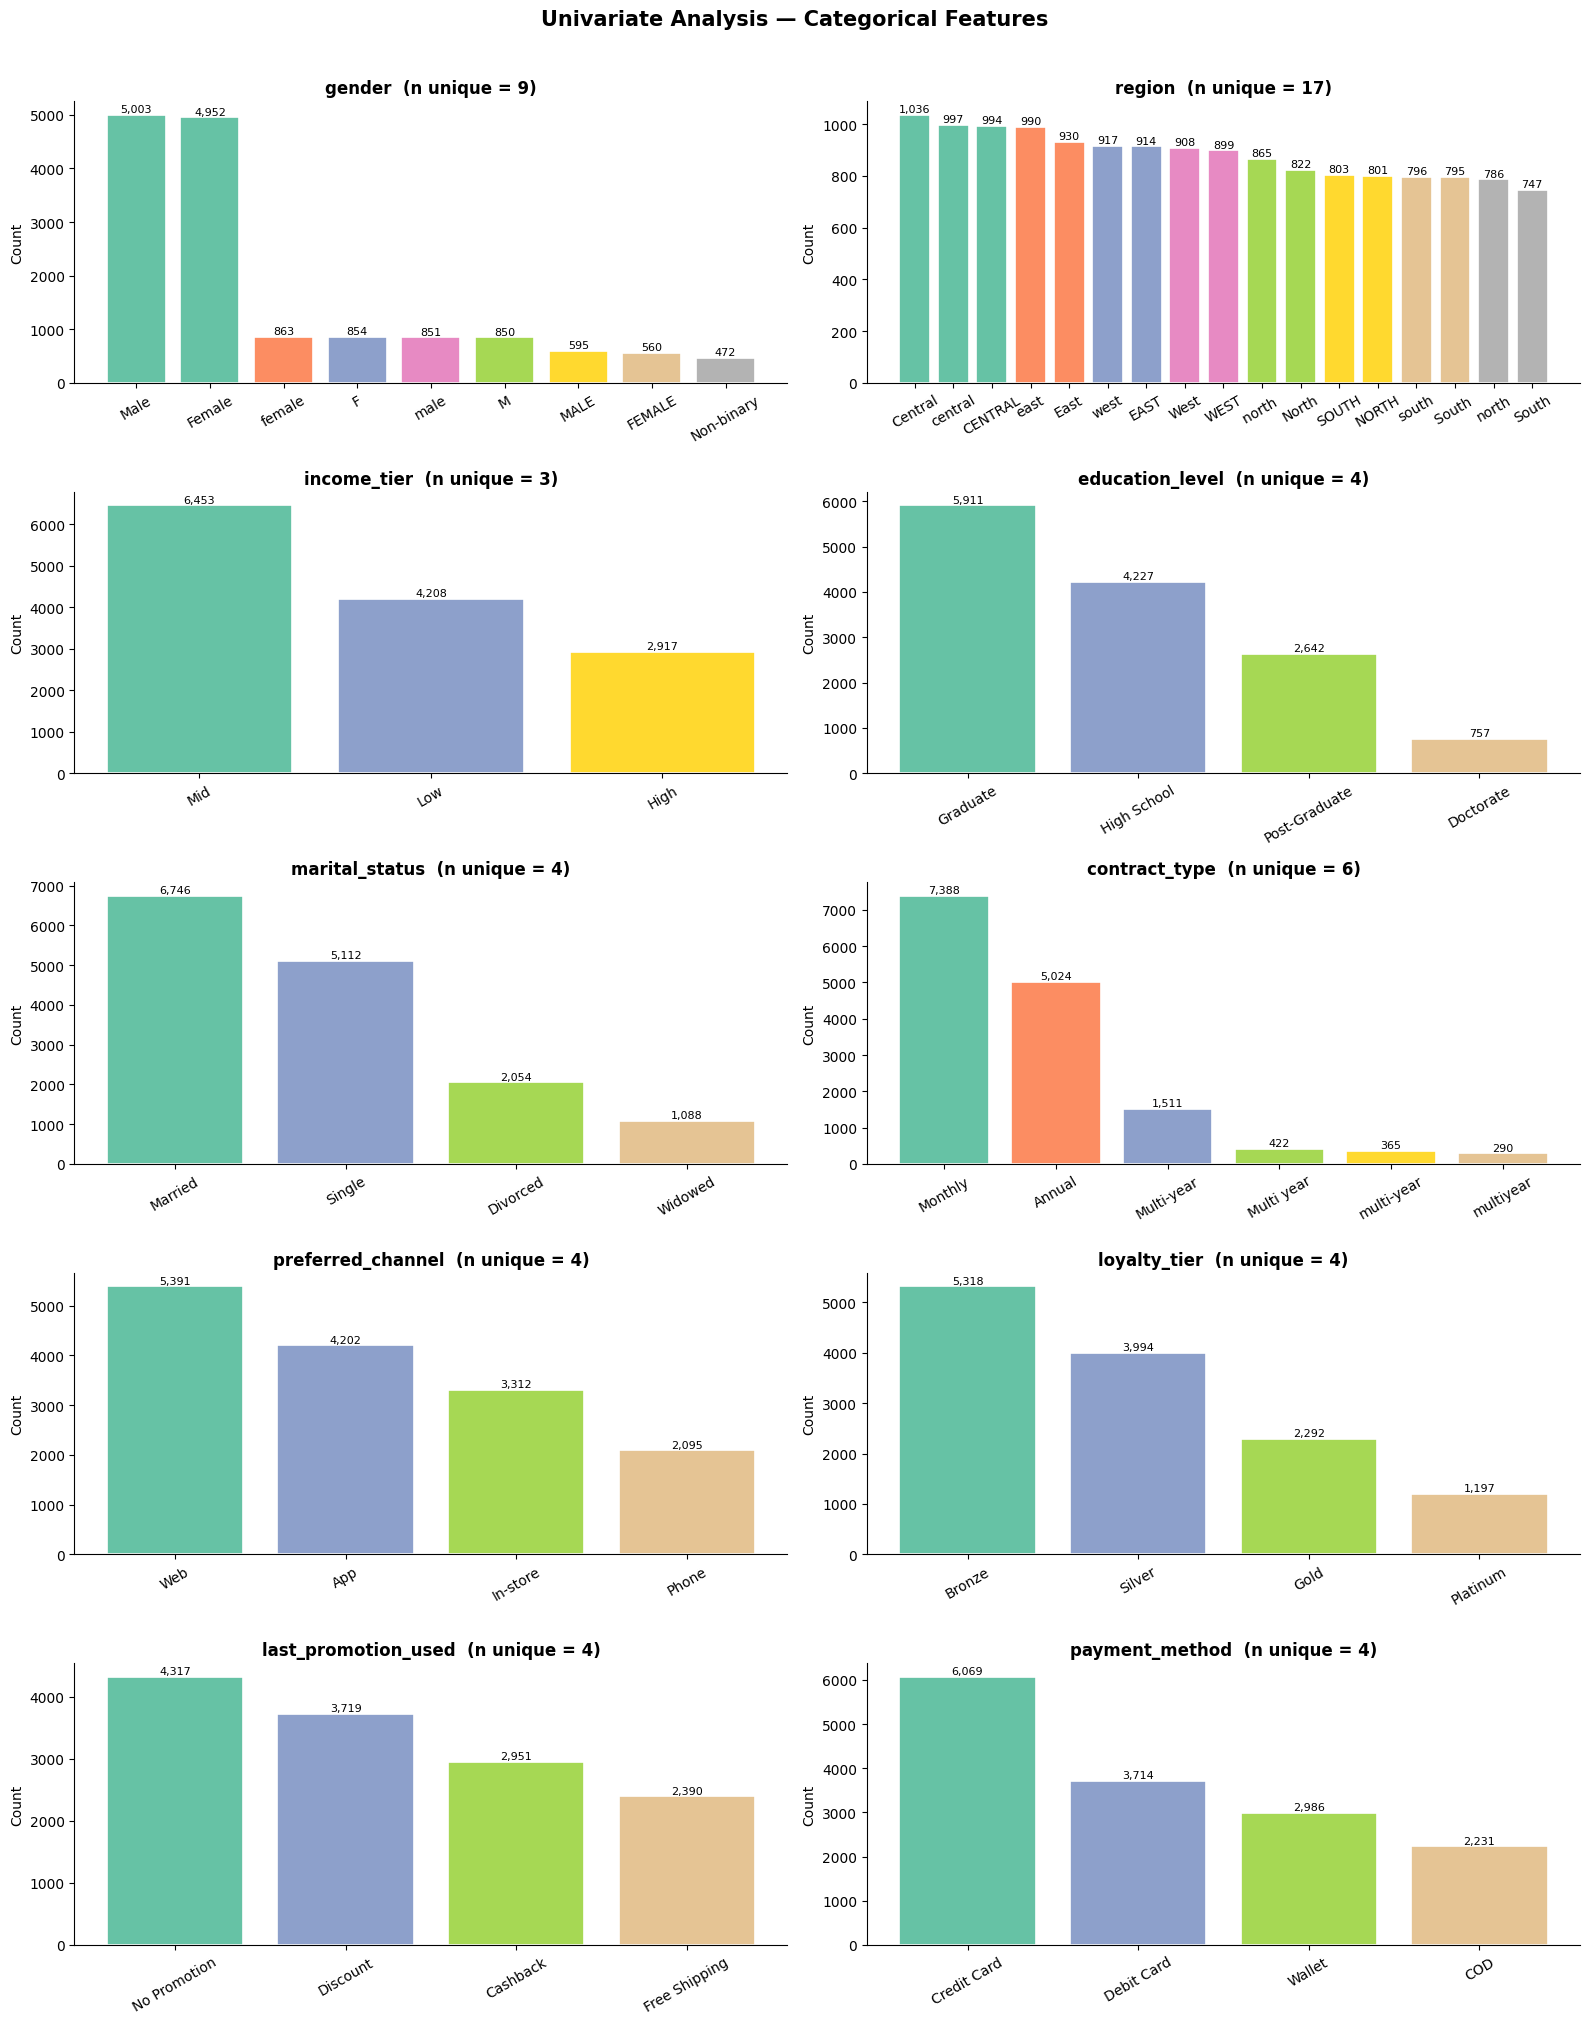

In [110]:
cat_plot_cols = ['gender', 'region', 'income_tier', 'education_level',
                 'marital_status', 'contract_type', 'preferred_channel',
                 'loyalty_tier', 'last_promotion_used', 'payment_method']

n_cols = 2
n_rows = (len(cat_plot_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

cmap = plt.get_cmap('Set2')

for i, col in enumerate(cat_plot_cols):
    vc = train[col].value_counts()
    colors = [cmap(j / len(vc)) for j in range(len(vc))]
    bars = axes[i].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{col}  (n unique = {train[col].nunique()})', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + vc.max() * 0.01,
                     f'{bar.get_height():,.0f}', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Categorical Features:

* **Data Cleaning Required (High Priority):** * `gender` and `region` have severe data entry issues due to inconsistent casing and naming (e.g., 'Male', 'male', 'M', 'MALE' / 'Central', 'central', 'CENTRAL'). These must be standardized before modeling.
* `contract_type` contains redundant duplicate categories ('Multi-year', 'Multi year', 'multi-year', 'multiyear') that need merging.


* **Ordinal Distributions:** `income_tier`, `education_level`, and `loyalty_tier` all follow a consistent, expected downward trend from lowest tier (highest volume) to highest tier (lowest volume).
* **Class Imbalance:** `contract_type` is heavily skewed toward short-term commitment, with `Monthly` and `Annual` plans making up the vast majority of the dataset.
* **Transactional Preferences:** Customers strongly favor digital engagement over physical channels, as seen in the clear dominance of `Web`/`App` in `preferred_channel` and `Credit Card` in `payment_method`.

### 3.5 Bivariate Analysis

#### 3.5.1 Categorical Features vs Churn <a id='8'></a>

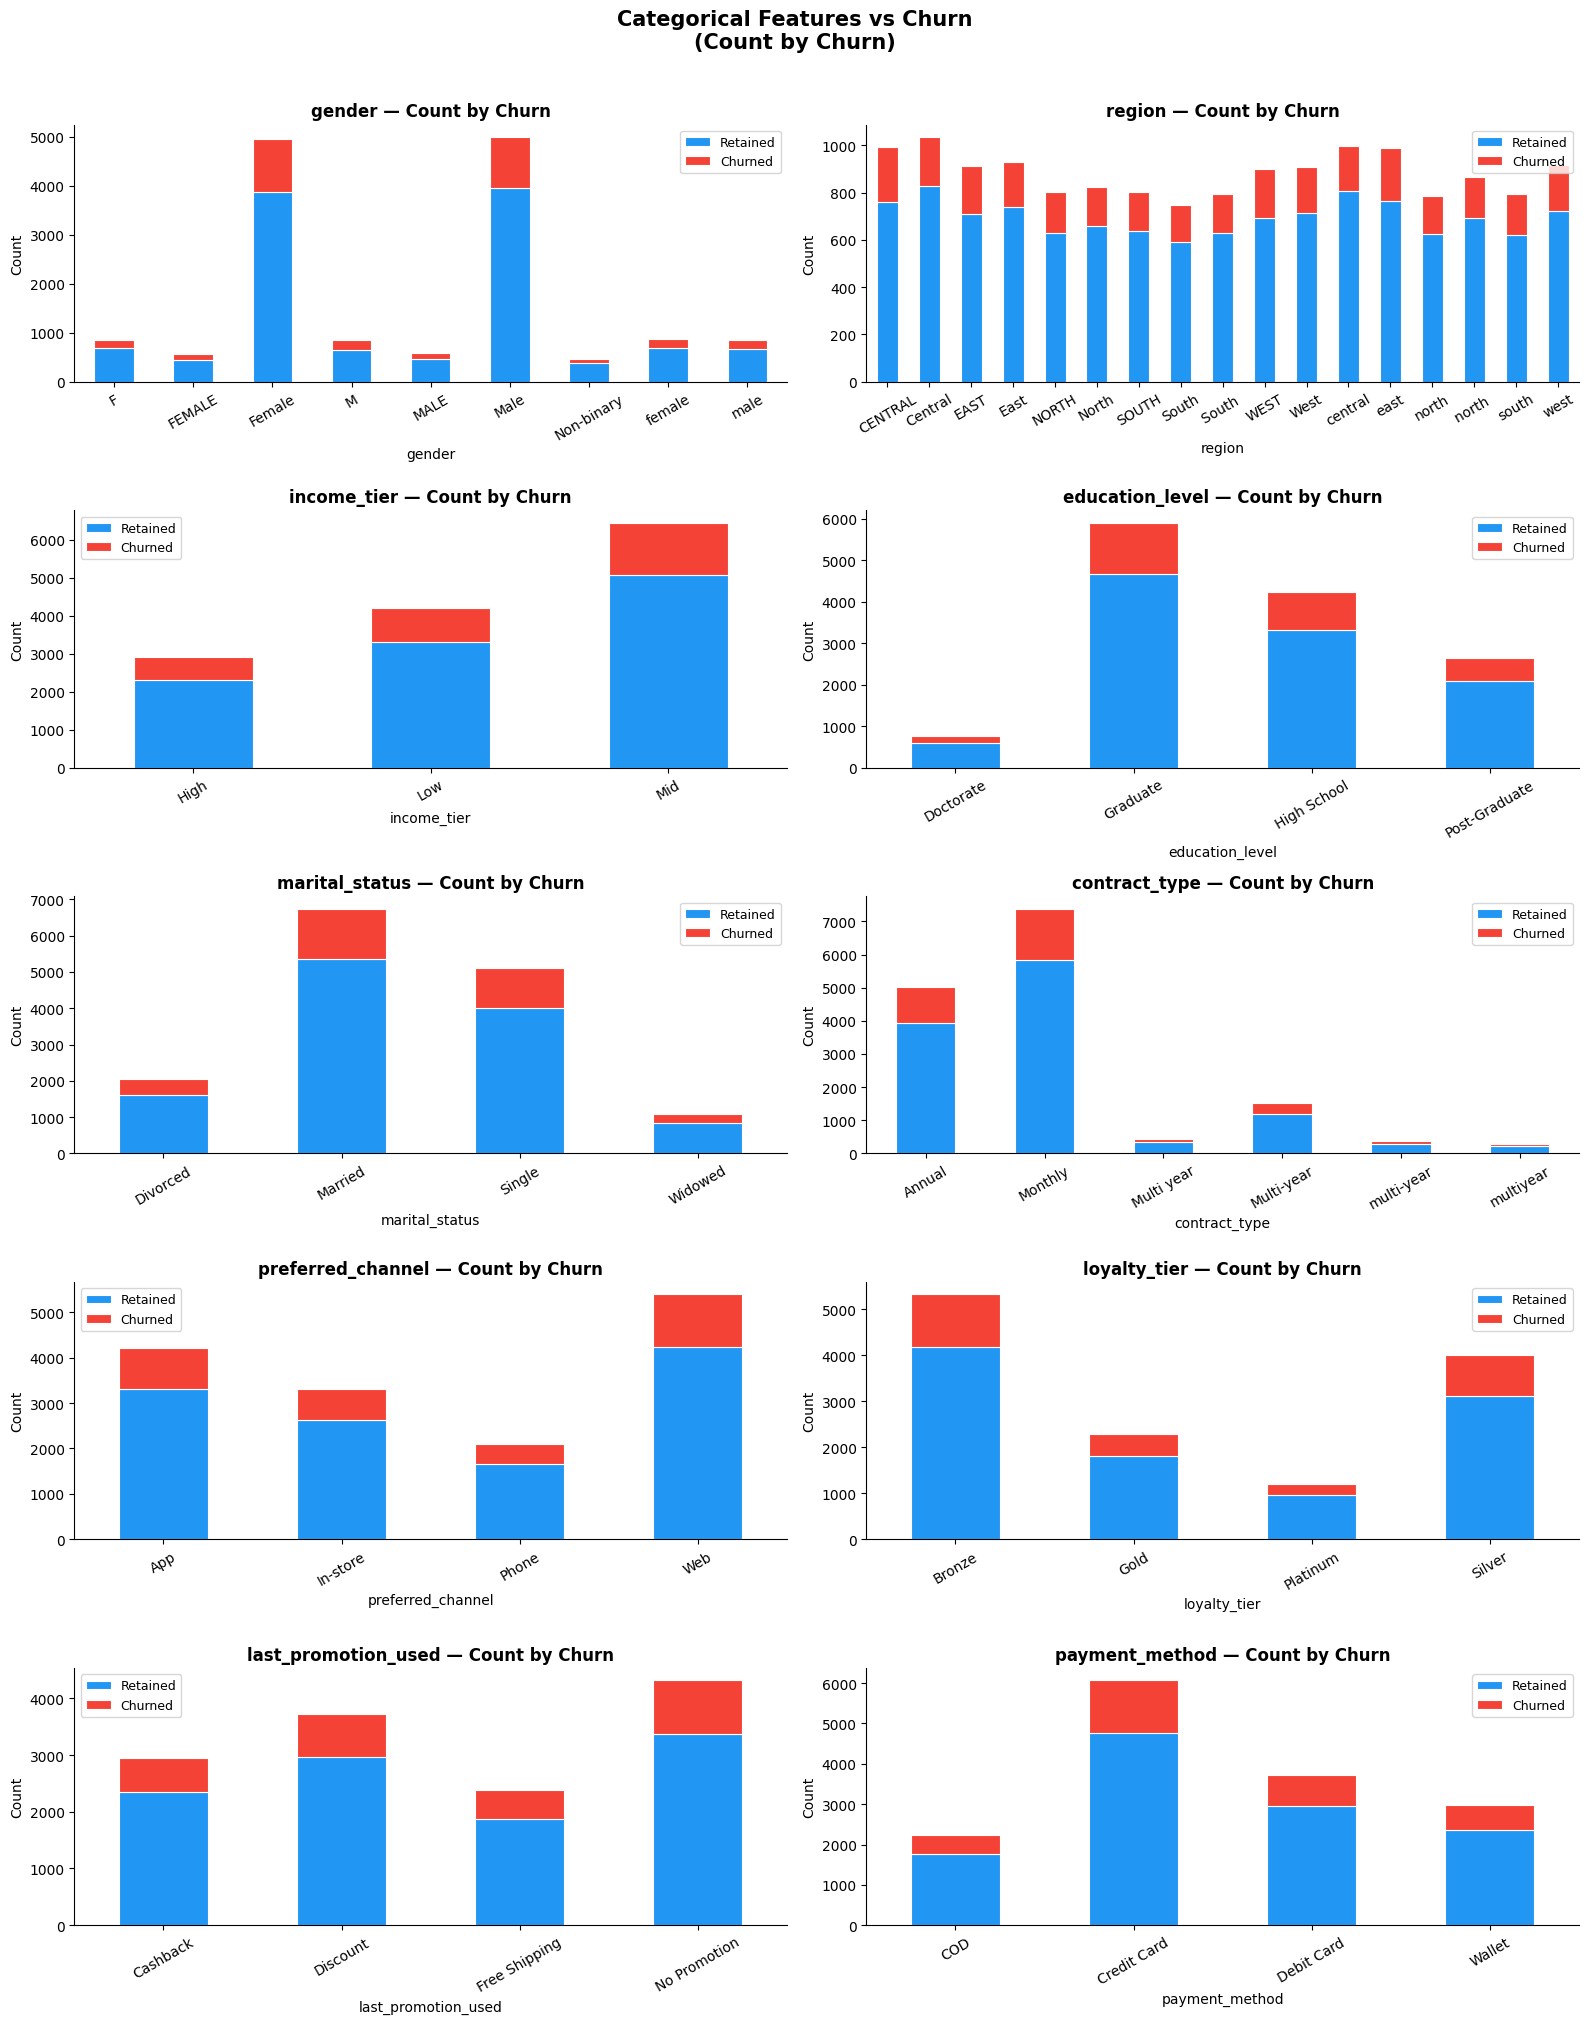

In [111]:
n_cols = 2
n_rows = (len(cat_plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = np.atleast_1d(axes).flatten()

fig.suptitle('Categorical Features vs Churn\n(Count by Churn)',
             fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(cat_plot_cols):
    ct = train.groupby([col, 'churn']).size().unstack(fill_value=0)
    cols = ct.columns.tolist()
    col_colors = [(PALETTE['Retained'] if c == 0 else PALETTE['Churned'] if c == 1 else '#CCCCCC')
                  for c in cols]

    ct.plot(kind='bar', stacked=True, ax=axes[i], color=col_colors,
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col} — Count by Churn', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    legend_labels = ['Retained' if c == 0 else 'Churned' if c == 1 else str(c) for c in cols]
    axes[i].legend(legend_labels, fontsize=9)

# Hide any unused subplots
for j in range(len(cat_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


#### Categorical Features vs Churn:

* **Strongest Churn Predictors:** 
    * **contract_type:** `Monthly` contracts show both the highest absolute volume and a significantly higher ratio of churned users compared to `Annual` and `Multi-Year` plans.
    * **preferred_channel:** Users preferring digital channels (`Web` and `App`) have a noticeably larger proportion of churn compared to traditional physical/assisted channels (`In-store`, `Phone`).
* **High-Volume Risk Pools:**
    * **payment_method:** While `Credit Card` has the largest user base, it also holds the largest absolute volume of churned customers. 
    * **income_tier & education_level:** `Mid` income tiers and `Graduate` level individuals contribute the highest raw volume of churned cases, reflecting the overall dataset distribution.
* **Low Impact / Even Distribution:**
    * **gender & region:** Churn ratios appear highly consistent and uniform across all sub-categories, indicating these variables offer weak predictive signal on their own.
    * **loyalty_tier & last_promotion_used:** Proportional churn rates stay relatively stable across their respective segments, though `Bronze` (loyalty) and `Discount` (promotion) visually carry the heaviest absolute count of churned accounts.

#### 3.5.2 Correlation Matrix <a id='8'></a>

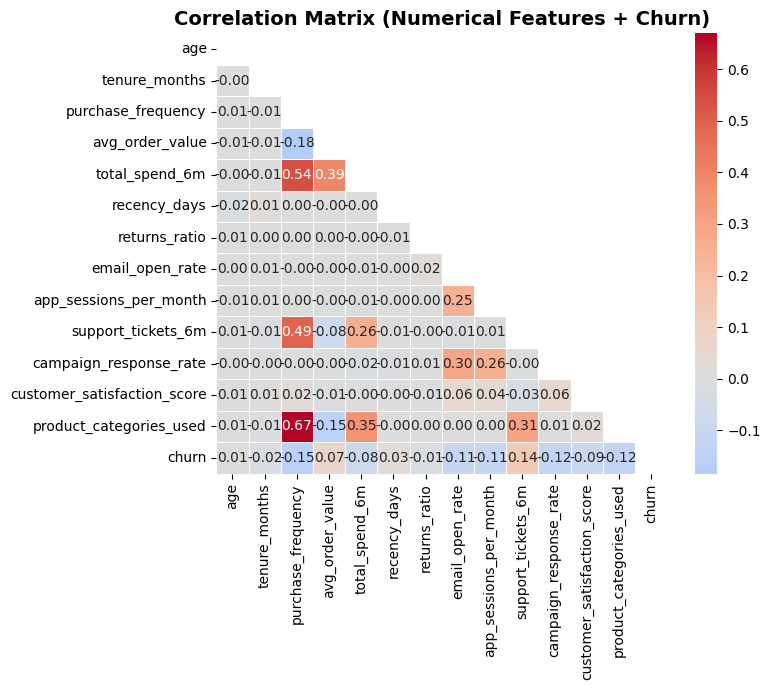

In [112]:
corr = train[num_cols + ['churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numerical Features + Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Correlation Matrix Analysis: Key Observations

* **Top Churn Correlations:** 
    * `support_tickets_6m` has the strongest positive correlation with `churn` (0.14), indicating that customers with more support issues are more likely to churn.
    * `purchase_frequency` has the strongest negative correlation with `churn` (-0.15), meaning higher engagement directly links to retention.

* **Strong Feature Multicollinearity:**
    * `product_categories_used` is highly correlated with `purchase_frequency` (0.67).
    * `total_spend_6m` shows strong positive ties with both `purchase_frequency` (0.54) and `avg_order_value` (0.39).
    * `support_tickets_6m` is noticeably correlated with `purchase_frequency` (0.49), suggesting high-frequency buyers naturally open more tickets due to sheer volume of interactions.

* **Marketing & Engagement Sync:** 
    * `email_open_rate` and `campaign_response_rate` share a moderate positive correlation (0.30). They both also exhibit slight negative correlations with `churn` (-0.11 and -0.12), proving that baseline marketing engagement tracks with retention.

* **Highly Independent Features:**
    * Demographic and baseline timeline features like `age`, `tenure_months`, and `recency_days` show near-zero correlation with all other numerical metrics and churn, implying they act as independent dimensions in the dataset.

## 4. Data Cleaning

In [113]:
from rapidfuzz import process, fuzz
import numpy as np

# -----------------------------------
# Special replacements
# -----------------------------------
SPECIAL = {
    'gender': {
        'f': 'female',
        'm': 'male'
    }
}


# -----------------------------------
# Generic text cleaning function
# -----------------------------------
def clean_col(s, special=None):

    # Basic standardisation
    s = (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[-_]', ' ', regex=True)
         .str.replace(r'\s+', ' ', regex=True)
    )

    vals = s.unique()
    mapping = {}

    # Fuzzy matching
    for v in vals:

        matches = process.extract(
            v,
            vals,
            scorer=fuzz.ratio,
            limit=None
        )

        similar = [
            m for m, score, _ in matches
            if score >= 90
        ]

        canon = min(similar, key=len)

        for m in similar:
            mapping[m] = canon

    s = s.replace(mapping)

    # Apply manual replacements
    if special:
        s = s.replace(special)

    return s


# -----------------------------------
# Main cleaning function
# -----------------------------------
def clean_data(df):

    df = df.copy()

    # -----------------------------------
    # 1. Clean categorical columns
    # -----------------------------------
    cols_to_clean = [
        'gender',
        'region',
        'contract_type',
        'marital_status'
    ]

    for col in cols_to_clean:

        if col in df.columns:

            df[col] = clean_col(
                df[col],
                SPECIAL.get(col)
            )

    # -----------------------------------
    # 2. Standardise final labels
    # -----------------------------------

    # Gender
    gender_map = {
        'male': 'Male',
        'female': 'Female',
        'non binary': 'Non-binary'
    }

    if 'gender' in df.columns:
        df['gender'] = df['gender'].replace(gender_map)

    # Region
    if 'region' in df.columns:
        df['region'] = df['region'].str.title()

    # Contract Type
    contract_map = {
        'multiyear': 'Multi-year',
        'multi year': 'Multi-year',
        'multi-year': 'Multi-year'
    }

    if 'contract_type' in df.columns:
        df['contract_type'] = (
            df['contract_type']
            .replace(contract_map)
            .str.title()
        )

    # Marital Status
    if 'marital_status' in df.columns:
        df['marital_status'] = df['marital_status'].str.title()

    # -----------------------------------
    # 3. Impute purchase_frequency
    # purchase_frequency = total_spend_6m / avg_order_value
    # -----------------------------------
    if all(col in df.columns for col in [
        'purchase_frequency',
        'total_spend_6m',
        'avg_order_value'
    ]):

        mask = df['purchase_frequency'].isna()

        df.loc[mask, 'purchase_frequency'] = (
            df.loc[mask, 'total_spend_6m'] /
            df.loc[mask, 'avg_order_value']
        ).round()

    # -----------------------------------
    # 4. Cap outliers using percentile clipping
    # -----------------------------------
    outlier_cols = [
        'avg_order_value',
        'total_spend_6m',
        'recency_days',
        'app_sessions_per_month',
        'support_tickets_6m'
    ]

    for col in outlier_cols:

        if col in df.columns:

            q_low = df[col].quantile(0.01)
            q_high = df[col].quantile(0.99)

            df[col] = df[col].clip(
                lower=q_low,
                upper=q_high
            )

    # -----------------------------------
    # 5. Logical fixes
    # -----------------------------------
    if 'returns_ratio' in df.columns:
        df['returns_ratio'] = df['returns_ratio'].clip(0, 1)

    return df


# -----------------------------------
# Apply cleaning
# -----------------------------------
train_clean = clean_data(train)
test_clean = clean_data(test)

print("Cleaning completed.")

print("\nGender values:")
print(sorted(train_clean['gender'].dropna().unique()))

print("\nRegion values:")
print(sorted(train_clean['region'].dropna().unique()))

print("\nContract type values:")
print(sorted(train_clean['contract_type'].dropna().unique()))

print("\nMarital status values:")
print(sorted(train_clean['marital_status'].dropna().unique()))

Cleaning completed.

Gender values:
['Female', 'Male', 'Non-binary']

Region values:
['Central', 'East', 'North', 'South', 'West']

Contract type values:
['Annual', 'Monthly', 'Multi-Year']

Marital status values:
['Divorced', 'Married', 'Single', 'Widowed']


### 4.6 Churn Rate by Categorical Features (Post-Cleaning)

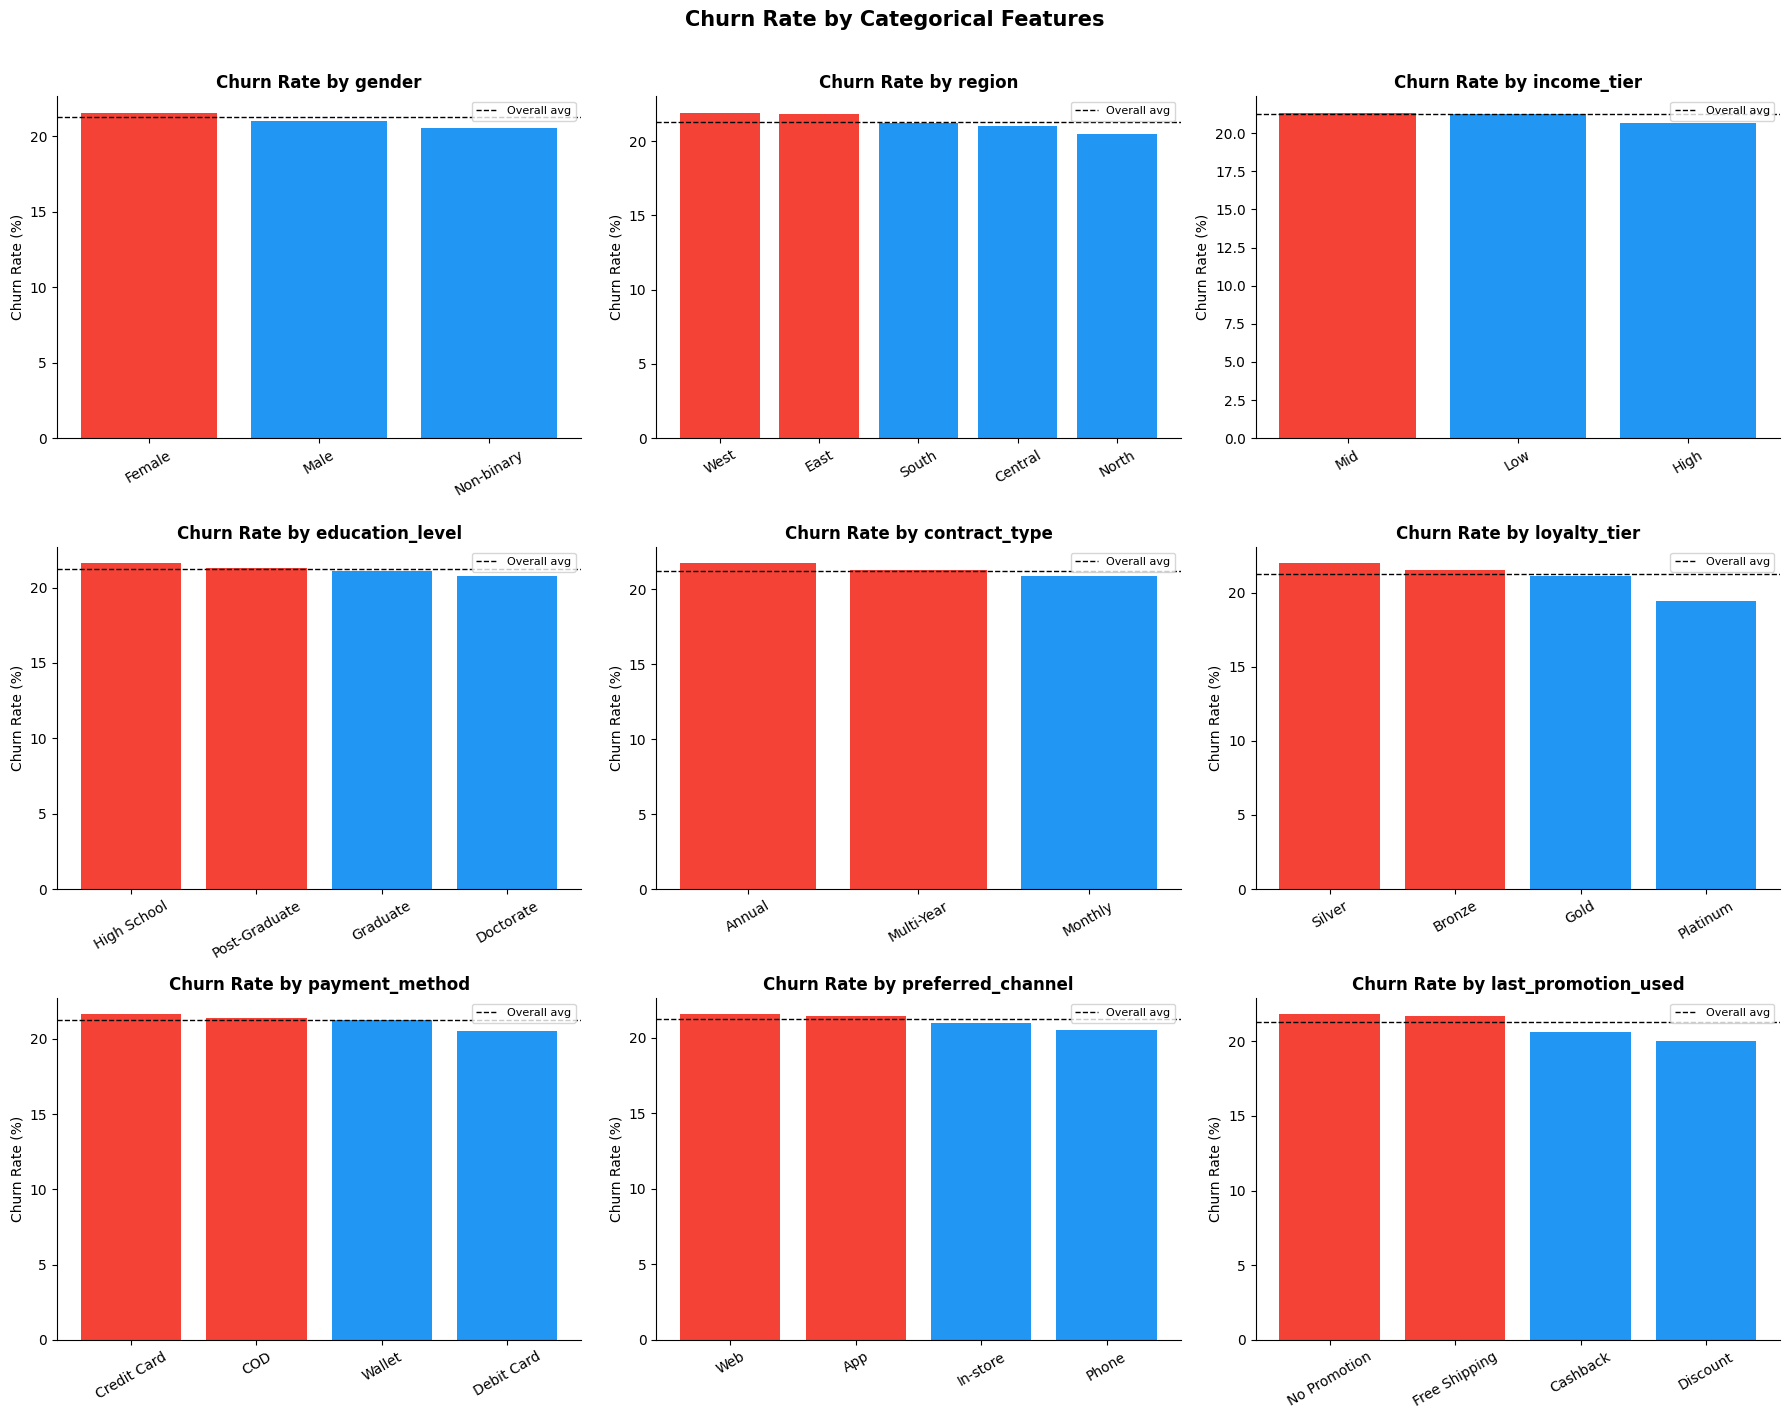

In [114]:
cat_plot_cols = ['gender', 'region', 'income_tier', 'education_level',
                 'contract_type', 'loyalty_tier', 'payment_method',
                 'preferred_channel', 'last_promotion_used']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    churn_rate = train_clean.groupby(col)['churn'].mean().sort_values(ascending=False)
    colors_bar = ['#F44336' if v > train_clean['churn'].mean() else '#2196F3'
                  for v in churn_rate.values]
    axes[i].bar(churn_rate.index, churn_rate.values * 100, color=colors_bar)
    axes[i].axhline(train_clean['churn'].mean() * 100, color='black', linestyle='--',
                    linewidth=1, label='Overall avg')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [115]:
import numpy as np
import pandas as pd


def engineer_features(df):
    """
    Leakage-safe feature engineering for customer churn prediction.
    """

    df = df.copy()

    # =========================================================
    # SAFE DENOMINATORS
    # =========================================================
    purchase_denom = df['purchase_frequency'].replace(0, np.nan)
    tenure_denom = df['tenure_months'].replace(0, np.nan)
    session_denom = df['app_sessions_per_month'].replace(0, np.nan)
    category_denom = df['product_categories_used'].replace(0, np.nan)

    # =========================================================
    # 1. CUSTOMER VALUE FEATURES
    # =========================================================

    # Average spend per purchase
    df['spend_per_purchase'] = (
        df['total_spend_6m'] / purchase_denom
    ).replace([np.inf, -np.inf], np.nan)

    # Monthly customer value
    df['monthly_customer_value'] = (
        df['total_spend_6m'] / tenure_denom
    ).replace([np.inf, -np.inf], np.nan)

    # Spend distribution across categories
    df['spend_per_category'] = (
        df['total_spend_6m'] / category_denom
    ).replace([np.inf, -np.inf], np.nan)

    # =========================================================
    # 2. ENGAGEMENT FEATURES
    # =========================================================

    # Composite engagement score
    max_sessions = max(df['app_sessions_per_month'].max(), 1)

    df['engagement_score'] = (
        (0.45 * df['email_open_rate'].fillna(0)) +
        (0.35 * df['campaign_response_rate'].fillna(0)) +
        (0.20 * (
            df['app_sessions_per_month'].fillna(0) / max_sessions
        ))
    )

    # Sessions needed before purchase
    df['sessions_per_purchase'] = (
        df['app_sessions_per_month'] / purchase_denom
    ).replace([np.inf, -np.inf], np.nan)

    # Purchase conversion efficiency
    df['purchase_conversion_efficiency'] = (
        df['purchase_frequency'] / session_denom
    ).replace([np.inf, -np.inf], np.nan)

    # =========================================================
    # 3. RISK FEATURES
    # =========================================================

    # Total returns volume
    df['returns_volume'] = (
        df['returns_ratio'].fillna(0) *
        df['purchase_frequency']
    )

    # Support ticket frequency adjusted by tenure
    df['support_ticket_rate'] = (
        df['support_tickets_6m'] / tenure_denom
    ).replace([np.inf, -np.inf], np.nan)

    # Composite dissatisfaction score
    satisfaction_fill = df[
        'customer_satisfaction_score'
    ].median()

    df['dissatisfaction_score'] = (
        (2 * df['returns_ratio'].fillna(0)) +
        (0.5 * df['support_tickets_6m']) +
        (
            1 / (
                df['customer_satisfaction_score']
                .fillna(satisfaction_fill) + 1
            )
        )
    )

    # Relative inactivity severity
    df['inactivity_score'] = (
        df['recency_days'] / tenure_denom
    ).replace([np.inf, -np.inf], np.nan)

    # =========================================================
    # 4. LOYALTY & CONTRACT FEATURES
    # =========================================================

    loyalty_map = {
        'Bronze': 1,
        'Silver': 2,
        'Gold': 3,
        'Platinum': 4
    }

    df['loyalty_rank'] = (
        df['loyalty_tier']
        .map(loyalty_map)
        .fillna(1)
    )

    # Monthly contracts are easier to churn
    df['monthly_contract_flag'] = (
        df['contract_type'] == 'Monthly'
    ).astype(int)

    # Structural churn risk
    df['loyalty_contract_risk'] = (
        (5 - df['loyalty_rank']) *
        df['monthly_contract_flag']
    )

    # Long tenure but low loyalty
    df['tenure_loyalty_gap'] = (
        (df['tenure_months'] >= 24) &
        (df['loyalty_rank'] <= 2)
    ).astype(int)

    # =========================================================
    # 5. CUSTOMER BEHAVIOUR FLAGS
    # =========================================================

    df['low_engagement_flag'] = (
        (
            df['email_open_rate'].fillna(0) < 0.20
        ) &
        (
            df['campaign_response_rate'].fillna(0) < 0.15
        )
    ).astype(int)

    df['high_support_flag'] = (
        df['support_tickets_6m'] >= 10
    ).astype(int)

    df['high_recency_flag'] = (
        df['recency_days'] >= 90
    ).astype(int)

    df['high_return_flag'] = (
        df['returns_ratio'] >= 0.30
    ).astype(int)

    # =========================================================
    # 6. BUCKET FEATURES (Leakage-safe)
    # =========================================================

    df['tenure_bucket'] = pd.cut(
        df['tenure_months'],
        bins=[-1, 6, 12, 24, 48, np.inf],
        labels=[
            'new',
            'developing',
            'established',
            'loyal',
            'veteran'
        ]
    ).astype(object)

    df['recency_bucket'] = pd.cut(
        df['recency_days'],
        bins=[-1, 30, 60, 90, 180, np.inf],
        labels=[
            'active',
            'cooling',
            'at_risk',
            'inactive',
            'lost'
        ]
    ).astype(object)

    # FIXED bins instead of qcut (avoids leakage)
    df['spending_bucket'] = pd.cut(
        df['total_spend_6m'],
        bins=[-np.inf, 100, 500, 1500, np.inf],
        labels=[
            'low',
            'medium',
            'high',
            'premium'
        ]
    ).astype(object)

    # =========================================================
    # 7. AGE SEGMENTS
    # =========================================================

    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 50, 65, 120],
        labels=[
            '<25',
            '25-35',
            '35-50',
            '50-65',
            '65+'
        ]
    ).astype(object)

    df['age_group'] = df['age_group'].fillna('Unknown')

    # =========================================================
    # 8. HANDLE ENGINEERED NaNs
    # =========================================================

    engineered_nan_cols = [
        'spend_per_purchase',
        'monthly_customer_value',
        'spend_per_category',
        'sessions_per_purchase',
        'purchase_conversion_efficiency',
        'support_ticket_rate',
        'inactivity_score'
    ]

    for col in engineered_nan_cols:
        df[col] = df[col].fillna(0)

    return df


# =========================================================
# APPLY FEATURE ENGINEERING
# =========================================================
train_feat = engineer_features(train_clean)
test_feat  = engineer_features(test_clean)


# =========================================================
# FINAL FEATURE LISTS
# =========================================================

ENGINEERED_NUMERIC = [
    'spend_per_purchase',
    'monthly_customer_value',
    'spend_per_category',
    'engagement_score',
    'sessions_per_purchase',
    'purchase_conversion_efficiency',
    'returns_volume',
    'support_ticket_rate',
    'dissatisfaction_score',
    'inactivity_score',
    'loyalty_rank',
    'loyalty_contract_risk'
]

ENGINEERED_FLAGS = [
    'monthly_contract_flag',
    'tenure_loyalty_gap',
    'low_engagement_flag',
    'high_support_flag',
    'high_recency_flag',
    'high_return_flag'
]

ENGINEERED_CATEGORICAL = [
    'tenure_bucket',
    'recency_bucket',
    'spending_bucket',
    'age_group'
]

ALL_ENGINEERED_FEATURES = (
    ENGINEERED_NUMERIC +
    ENGINEERED_FLAGS +
    ENGINEERED_CATEGORICAL
)

print("Feature engineering completed.")
print(f"Total engineered features: {len(ALL_ENGINEERED_FEATURES)}")

display(train_feat[ALL_ENGINEERED_FEATURES].head())

Feature engineering completed.
Total engineered features: 22


,spend_per_purchase,monthly_customer_value,spend_per_category,engagement_score,sessions_per_purchase,purchase_conversion_efficiency,returns_volume,support_ticket_rate,dissatisfaction_score,inactivity_score,loyalty_rank,loyalty_contract_risk,monthly_contract_flag,tenure_loyalty_gap,low_engagement_flag,high_support_flag,high_recency_flag,high_return_flag,tenure_bucket,recency_bucket,spending_bucket,age_group
0,115.0600,64.4336,536.9467,0.1679,0.0000,0.0000,3.0184,0.0000,0.4508,6.4800,2.0000,3.0000,1,1,0,0,1,0,loyal,inactive,premium,35-50
1,97.8733,16.3122,293.6200,0.4286,11.0000,0.0909,0.5253,0.3889,3.8685,4.7778,2.0000,3.0000,1,0,0,0,0,0,established,at_risk,medium,25-35
2,37.1429,3.8806,43.3333,0.5336,3.2857,0.3043,0.9737,0.0000,0.2928,1.0746,1.0000,0.0000,0,1,0,0,0,0,veteran,at_risk,medium,Unknown
3,41.3219,33.7100,640.4900,0.3600,1.6129,0.6200,13.4168,0.2368,5.3839,2.9211,3.0000,2.0000,1,0,0,0,1,1,loyal,inactive,high,35-50
4,490.1500,44.5591,490.1500,0.1800,54.0000,0.0185,0.3355,0.8182,5.2118,13.8182,1.0000,0.0000,0,0,1,0,1,1,developing,inactive,medium,35-50


### 5.1 Correlation of Engineered Features with Churn

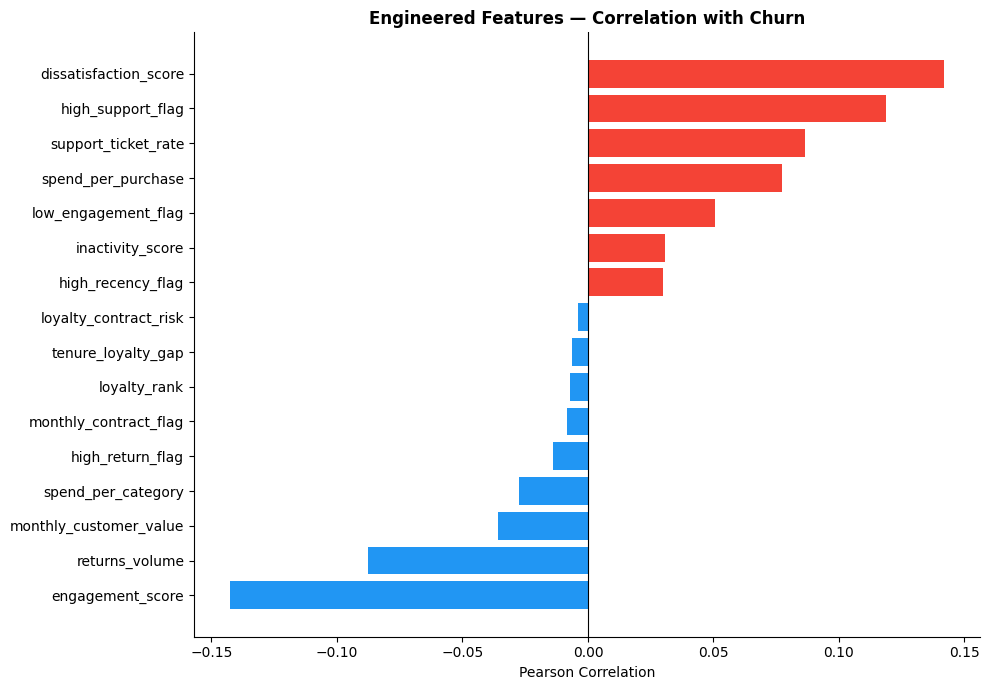

In [116]:
# -----------------------------------
# Engineered feature correlation
# -----------------------------------

eng_numeric = [
    'spend_per_purchase',
    'monthly_customer_value',
    'spend_per_category',
    'engagement_score',
    'returns_volume',
    'support_ticket_rate',
    'dissatisfaction_score',
    'inactivity_score',
    'loyalty_rank',
    'loyalty_contract_risk',
    'monthly_contract_flag',
    'tenure_loyalty_gap',
    'low_engagement_flag',
    'high_support_flag',
    'high_recency_flag',
    'high_return_flag'
]

# Correlation with churn
corr_eng = (
    train_feat[eng_numeric + ['churn']]
    .corr(numeric_only=True)['churn']
    .drop('churn')
    .sort_values()
)

# -----------------------------------
# Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

colors_bar = [
    '#F44336' if v > 0 else '#2196F3'
    for v in corr_eng.values
]

ax.barh(
    corr_eng.index,
    corr_eng.values,
    color=colors_bar
)

ax.axvline(0, color='black', linewidth=0.8)

ax.set_title(
    'Engineered Features — Correlation with Churn',
    fontweight='bold'
)

ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## 6. Customer Segmentation via Clustering

We cluster customers using RFM-inspired features to create a segment label, which becomes an additional input feature for the model.

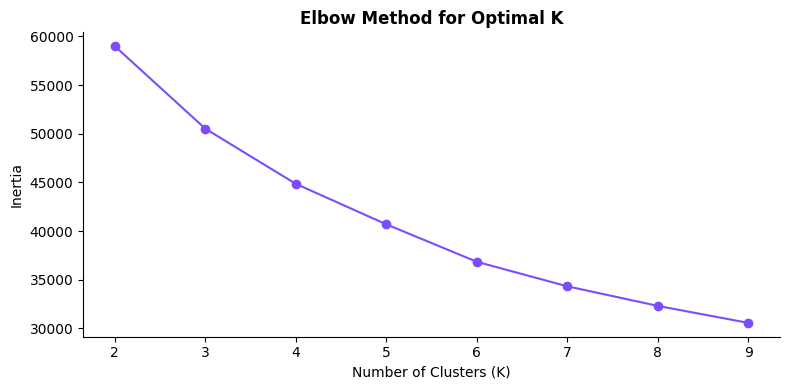

In [117]:
cluster_features = ['recency_days', 'purchase_frequency', 'total_spend_6m',
                    'customer_satisfaction_score', 'app_sessions_per_month']

def prepare_cluster_data(df):
    sub = df[cluster_features].copy()
    # Impute with median for clustering
    for c in cluster_features:
        sub[c] = sub[c].fillna(sub[c].median())
    return sub

cluster_data_train = prepare_cluster_data(train_feat)
cluster_data_test  = prepare_cluster_data(test_feat)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(cluster_data_train)

# Elbow method to find optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='#7C4DFF')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K', fontweight='bold')
plt.tight_layout()
plt.show()

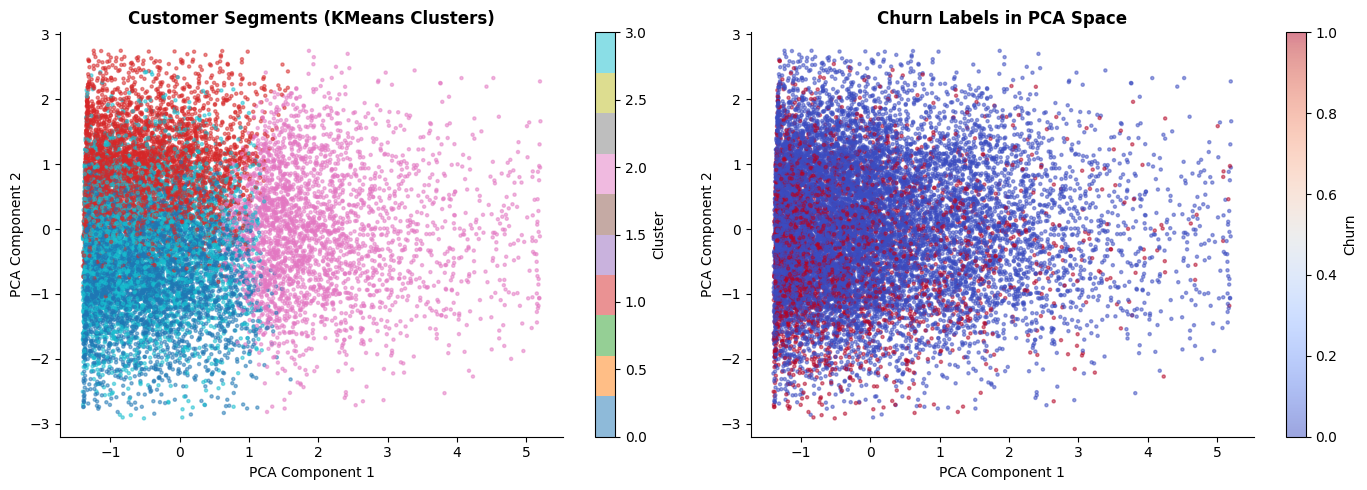


Churn rate per cluster:


,churn_rate,n_customers
cluster,,
0,0.2660,4260
1,0.1733,3953
2,0.1374,2824
3,0.2478,3963


In [118]:
# Fit final clustering model with K=4 (clear elbow)
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=SEED, n_init=10)
train_feat['cluster'] = kmeans.fit_predict(X_cluster_scaled)

X_test_cluster_scaled = scaler_cluster.transform(cluster_data_test)
test_feat['cluster'] = kmeans.predict(X_test_cluster_scaled)

# Visualise clusters with PCA (2D)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=train_feat['cluster'], cmap='tab10', alpha=0.5, s=5)
axes[0].set_title('Customer Segments (KMeans Clusters)', fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=train_feat['churn'], cmap='coolwarm', alpha=0.5, s=5)
axes[1].set_title('Churn Labels in PCA Space', fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Churn')

plt.tight_layout()
plt.show()

# Churn rate per cluster
print('\nChurn rate per cluster:')
display(train_feat.groupby('cluster')['churn'].agg(['mean', 'count']).rename(
    columns={'mean': 'churn_rate', 'count': 'n_customers'}
).round(4))

## 7. Preprocessing Pipeline

In [121]:
# Define feature sets
DROP_COLS = ['customer_id', 'churn']

# After engineering, categorical cols
cat_cols = ['gender', 'region', 'income_tier', 'education_level',
            'marital_status', 'contract_type', 'preferred_channel',
            'loyalty_tier', 'last_promotion_used', 'payment_method', 'age_group']

# Numeric cols = everything else that's not dropped and not categorical
all_cols = [c for c in train_feat.columns if c not in DROP_COLS]
num_cols_all = [c for c in all_cols if c not in cat_cols]

print(f'Numeric features  : {len(num_cols_all)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Total features    : {len(all_cols)}')

# Numeric pipeline: impute median → scale
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

# Categorical pipeline: impute mode → label-encode
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,  num_cols_all),
    ('cat', categorical_pipeline, cat_cols)
])

# Prepare X, y
X_train_full = train_feat[all_cols]
y_train_full = train_feat['churn']
X_test_final = test_feat[all_cols]

# Hold-out split for evaluation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

print(f'\nTrain size : {X_train.shape}')
print(f'Val   size : {X_val.shape}')

Numeric features  : 35
Categorical features: 11
Total features    : 46

Train size : (12000, 46)
Val   size : (3000, 46)


## 8. Handling Class Imbalance

Before SMOTE: {0: 9450, 1: 2550}
After  SMOTE: {0: 9450, 1: 9450}
Before Tomek Links: {0: 9450, 1: 2550}
After  Tomek Links: {0: 8798, 1: 2550}


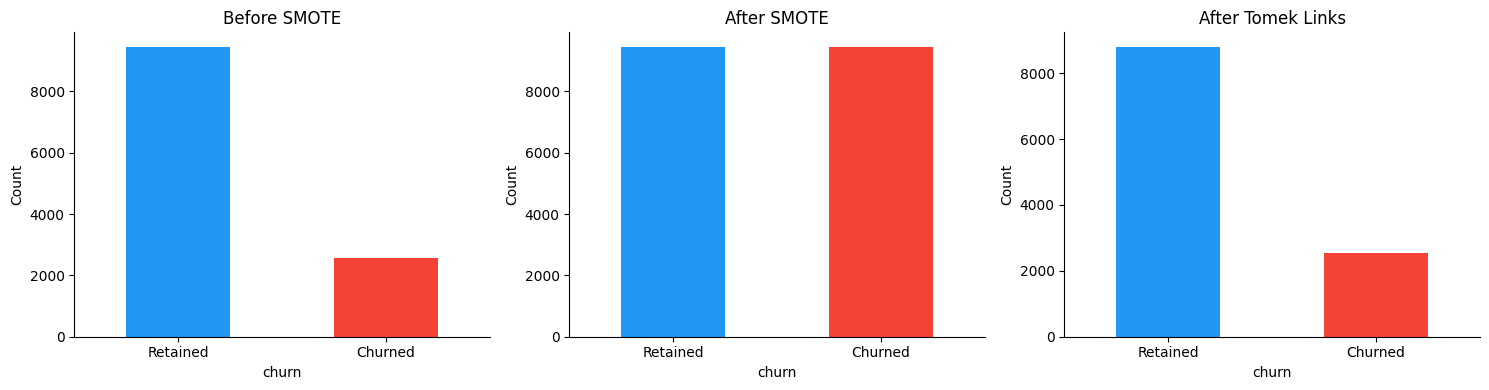

In [ ]:
# Final model trained on the full Tomek-resampled training data
final_model = lgb.LGBMClassifier(
    **best_params,
    objective='binary',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

final_model.fit(X_full_res_tl, y_full_res_tl)

# Predict on test set
test_probs  = final_model.predict_proba(X_test_proc)[:, 1]
test_labels = final_model.predict(X_test_proc)

submission = pd.DataFrame({
    'customer_id': test['customer_id'],
    'predicted_churn': test_labels
})

submission_path = OUTPUT_DIR / 'churn_predictions.csv'
submission.to_csv(submission_path, index=False)
print(f'Predictions saved to {submission_path}')
display(submission.head(10))

## 9. Model Training & Comparison

In [141]:
from sklearn.metrics import accuracy_score

def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'Decision Tree'      : DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                       random_state=SEED, n_jobs=-1),
        'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
        'XGBoost'            : xgb.XGBClassifier(scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                                   eval_metric='logloss', random_state=SEED, n_jobs=-1),
        'LightGBM'           : lgb.LGBMClassifier(class_weight='balanced', random_state=SEED,
                                                   n_jobs=-1, verbose=-1)
    }

datasets = {
    'SMOTE' : (X_train_res,   y_train_res),
    'Tomek' : (X_train_res_1, y_train_res_1)
}

results = []
fitted_models = {}

for ds_name, (Xr, yr) in datasets.items():
    print(f'\n--- Training on {ds_name} (n={len(yr)}) ---')
    for name, model in get_models().items():
        model = model  # fresh instance from get_models()
        model.fit(Xr, yr)
        y_pred = model.predict(X_val_proc)
        y_prob = model.predict_proba(X_val_proc)[:, 1]

        auc = roc_auc_score(y_val, y_prob)
        f1  = f1_score(y_val, y_pred)
        ap  = average_precision_score(y_val, y_prob)
        acc = accuracy_score(y_val, y_pred)

        results.append({
            'Dataset': ds_name,
            'Model': name,
            'ROC-AUC': auc,
            'Accuracy': acc,
            'F1-Score': f1,
            'Avg Precision': ap
        })

        fitted_models[(ds_name, name)] = model
        print(f'{ds_name} | {name:<20} ROC-AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}  AvgPrecision={ap:.4f}')

results_df = pd.DataFrame(results).sort_values(['Dataset', 'ROC-AUC'], ascending=[True, False]).reset_index(drop=True)
print('\n--- Combined Leaderboard ---')
display(results_df)


--- Training on SMOTE (n=18900) ---
SMOTE | Logistic Regression  ROC-AUC=0.7210  Acc=0.6680  F1=0.4639  AvgPrecision=0.4556
SMOTE | Decision Tree        ROC-AUC=0.5983  Acc=0.7107  F1=0.3719  AvgPrecision=0.2661
SMOTE | Random Forest        ROC-AUC=0.7416  Acc=0.8267  F1=0.5149  AvgPrecision=0.5249
SMOTE | Gradient Boosting    ROC-AUC=0.7625  Acc=0.8340  F1=0.4990  AvgPrecision=0.5632
SMOTE | XGBoost              ROC-AUC=0.7306  Acc=0.7730  F1=0.4837  AvgPrecision=0.5098
SMOTE | LightGBM             ROC-AUC=0.7718  Acc=0.8333  F1=0.5088  AvgPrecision=0.5707

--- Training on Tomek (n=11348) ---
Tomek | Logistic Regression  ROC-AUC=0.7223  Acc=0.6613  F1=0.4636  AvgPrecision=0.4578
Tomek | Decision Tree        ROC-AUC=0.6089  Acc=0.7300  F1=0.3854  AvgPrecision=0.2767
Tomek | Random Forest        ROC-AUC=0.7634  Acc=0.8253  F1=0.4165  AvgPrecision=0.5536
Tomek | Gradient Boosting    ROC-AUC=0.7701  Acc=0.8333  F1=0.4960  AvgPrecision=0.5683
Tomek | XGBoost              ROC-AUC=0.7570  A

,Dataset,Model,ROC-AUC,Accuracy,F1-Score,Avg Precision
0,SMOTE,LightGBM,0.7718,0.8333,0.5088,0.5707
1,SMOTE,Gradient Boosting,0.7625,0.8340,0.4990,0.5632
2,SMOTE,Random Forest,0.7416,0.8267,0.5149,0.5249
3,SMOTE,XGBoost,0.7306,0.7730,0.4837,0.5098
4,SMOTE,Logistic Regression,0.7210,0.6680,0.4639,0.4556
5,SMOTE,Decision Tree,0.5983,0.7107,0.3719,0.2661
6,Tomek,Gradient Boosting,0.7701,0.8333,0.4960,0.5683
7,Tomek,LightGBM,0.7687,0.7923,0.5585,0.5805
8,Tomek,Random Forest,0.7634,0.8253,0.4165,0.5536
9,Tomek,XGBoost,0.7570,0.8010,0.5439,0.5493


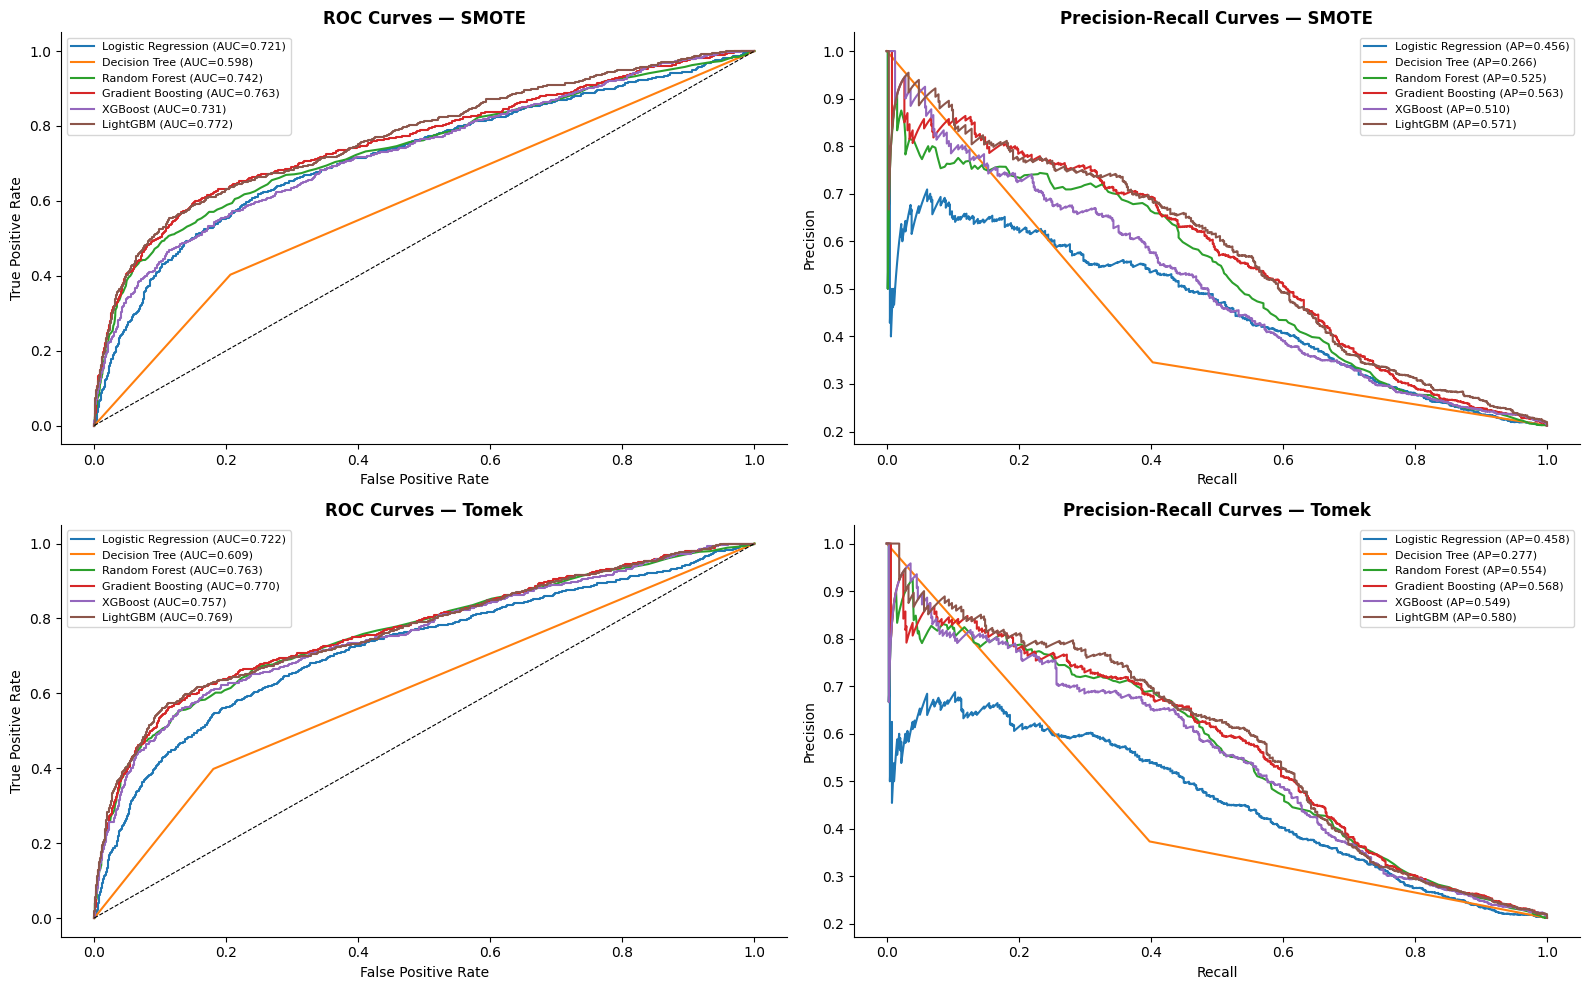

In [128]:
# ROC / PR for both SMOTE and Tomek-trained models
datasets = ['SMOTE', 'Tomek']
fig, axes = plt.subplots(len(datasets), 2, figsize=(16, 10))

for i, ds_name in enumerate(datasets):
    ax_roc = axes[i, 0]
    ax_pr  = axes[i, 1]

    ds_models = {
        name: model
        for (ds, name), model in fitted_models.items()
        if ds == ds_name
    }

    for name, model in ds_models.items():
        y_prob = model.predict_proba(X_val_proc)[:, 1]

        fpr, tpr, _ = roc_curve(y_val, y_prob)
        auc = roc_auc_score(y_val, y_prob)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

        prec, rec, _ = precision_recall_curve(y_val, y_prob)
        ap = average_precision_score(y_val, y_prob)
        ax_pr.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curves — {ds_name}', fontweight='bold')
    ax_roc.legend(fontsize=8)

    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall Curves — {ds_name}', fontweight='bold')
    ax_pr.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning — Best Model

In [142]:
lgbm_param_dist = {
    'n_estimators'      : randint(100, 1500),
    'max_depth'         : randint(3, 25),
    'learning_rate'     : uniform(0.003, 0.297),
    'num_leaves'        : randint(20, 256),
    'min_child_samples' : randint(5, 120),
    'subsample'         : uniform(0.4, 0.6),
    'colsample_bytree'  : uniform(0.4, 0.6),
    'reg_alpha'         : uniform(0, 2),
    'reg_lambda'        : uniform(0, 2)
}

lgbm_base = lgb.LGBMClassifier(class_weight='balanced', random_state=SEED,
                                 n_jobs=-1, verbose=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

tuned_search = {}
summary = []

ds_name = 'Tomek'
Xr, yr = X_train_res_1, y_train_res_1

print(f'\n--- Tuning LightGBM on {ds_name} ---')

rscv = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

rscv.fit(Xr, yr)

tuned_search[ds_name] = rscv
summary.append({
    'Dataset': ds_name,
    'Best CV ROC-AUC': rscv.best_score_,
    'Best Params': rscv.best_params_
})

print(f'Best CV ROC-AUC : {rscv.best_score_:.4f}')
print('Best params     :')
for k, v in rscv.best_params_.items():
    print(f'  {k}: {v}')

best_dataset = ds_name
best_model = rscv.best_estimator_

# Evaluate on validation set
y_prob_best = best_model.predict_proba(X_val_proc)[:, 1]
y_pred_best = best_model.predict(X_val_proc)

auc_best = roc_auc_score(y_val, y_prob_best)
f1_best = f1_score(y_val, y_pred_best)
acc_best = accuracy_score(y_val, y_pred_best)
ap_best = average_precision_score(y_val, y_prob_best)

print(f'\nValidation Performance (Tuned LightGBM on {best_dataset}):')
print(f'  ROC-AUC: {auc_best:.4f}')
print(f'  Accuracy: {acc_best:.4f}')
print(f'  F1-Score: {f1_best:.4f}')
print(f'  Avg Precision: {ap_best:.4f}')



--- Tuning LightGBM on Tomek ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV ROC-AUC : 0.7712
Best params     :
  colsample_bytree: 0.916438349953806
  learning_rate: 0.0050647827677636394
  max_depth: 10
  min_child_samples: 31
  n_estimators: 748
  num_leaves: 81
  reg_alpha: 0.4442156209414605
  reg_lambda: 0.2397307346673656
  subsample: 0.6025691028421768

Validation Performance (Tuned LightGBM on Tomek):
  ROC-AUC: 0.7745
  Accuracy: 0.7893
  F1-Score: 0.5479
  Avg Precision: 0.5849


In [144]:
best_model = rscv.best_estimator_

y_pred_best = best_model.predict(X_val_proc)
y_prob_best = best_model.predict_proba(X_val_proc)[:, 1]

acc_best = accuracy_score(y_val, y_pred_best)

print('=== Tuned LightGBM — Validation Performance ===')
print(f'ROC-AUC          : {roc_auc_score(y_val, y_prob_best):.4f}')
print(f'Accuracy         : {acc_best:.4f}')
print(f'F1-Score (churn) : {f1_score(y_val, y_pred_best):.4f}')
print(f'Avg Precision    : {average_precision_score(y_val, y_prob_best):.4f}')
print()
print(classification_report(y_val, y_pred_best, target_names=['Retained', 'Churned']))

=== Tuned LightGBM — Validation Performance ===
ROC-AUC          : 0.7745
Accuracy         : 0.7893
F1-Score (churn) : 0.5479
Avg Precision    : 0.5849

              precision    recall  f1-score   support

    Retained       0.89      0.84      0.86      2362
     Churned       0.50      0.60      0.55       638

    accuracy                           0.79      3000
   macro avg       0.70      0.72      0.71      3000
weighted avg       0.80      0.79      0.80      3000



## 11. Final Model Evaluation & Feature Importance

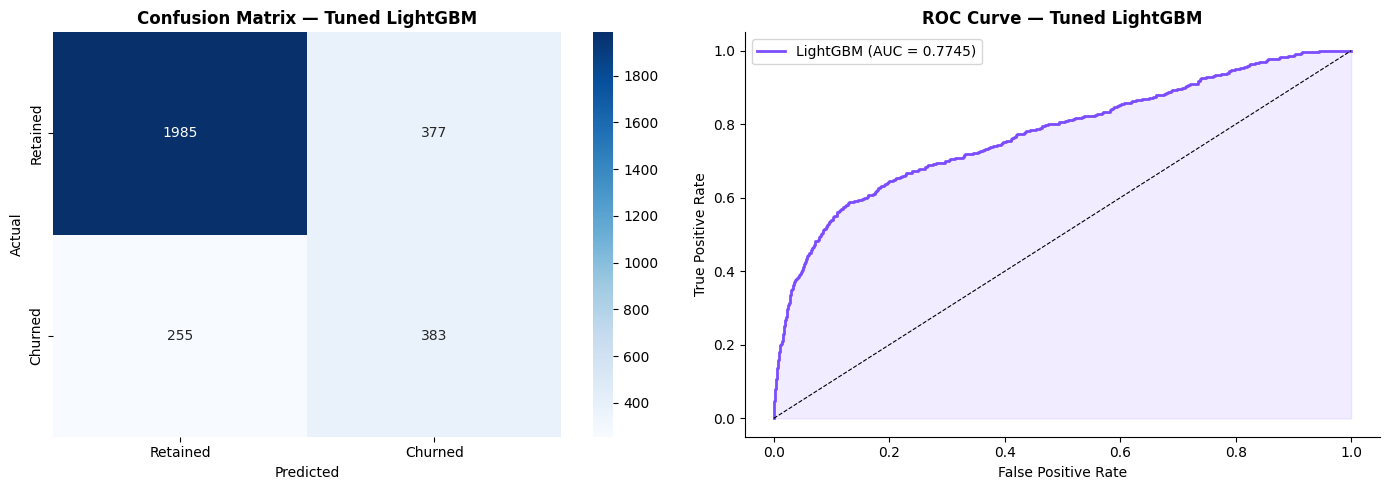

In [145]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
axes[0].set_title('Confusion Matrix — Tuned LightGBM', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC for best model
fpr, tpr, thresholds = roc_curve(y_val, y_prob_best)
auc_val = roc_auc_score(y_val, y_prob_best)
axes[1].plot(fpr, tpr, color='#7C4DFF', lw=2, label=f'LightGBM (AUC = {auc_val:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#7C4DFF')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Tuned LightGBM', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

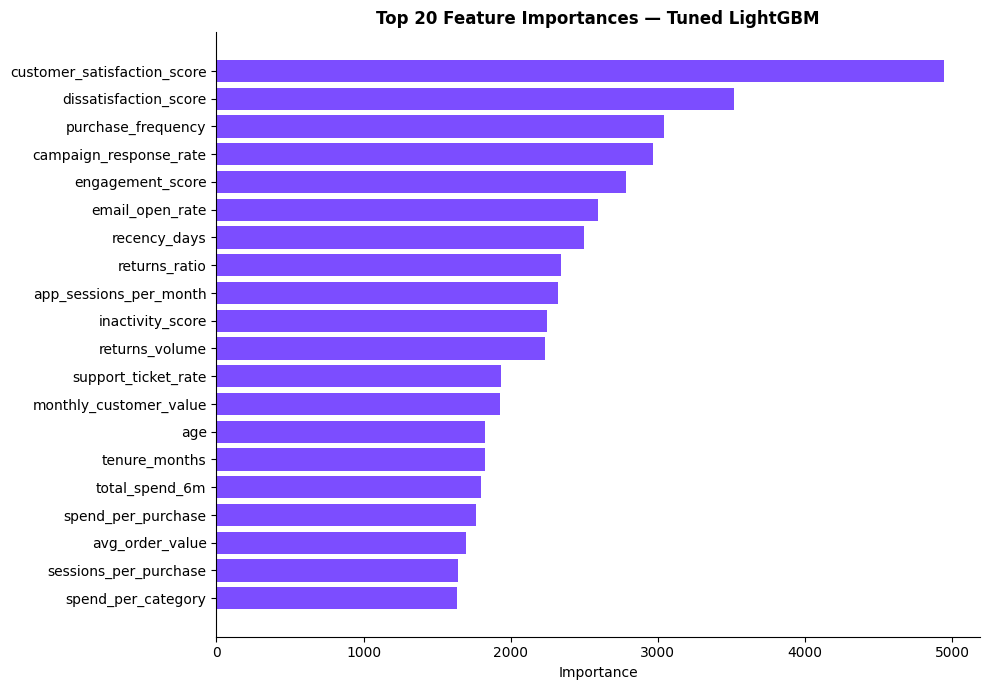

Top 10 most important features:


,Feature,Importance
12,customer_satisfaction_score,4941
21,dissatisfaction_score,3516
2,purchase_frequency,3040
11,campaign_response_rate,2967
16,engagement_score,2786
8,email_open_rate,2592
5,recency_days,2498
7,returns_ratio,2342
9,app_sessions_per_month,2323
22,inactivity_score,2245


In [134]:
# Feature Importance
feature_names = num_cols_all + cat_cols
importances   = best_model.feature_importances_

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='#7C4DFF')
ax.set_title('Top 20 Feature Importances — Tuned LightGBM', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
display(feat_imp_df.head(10))

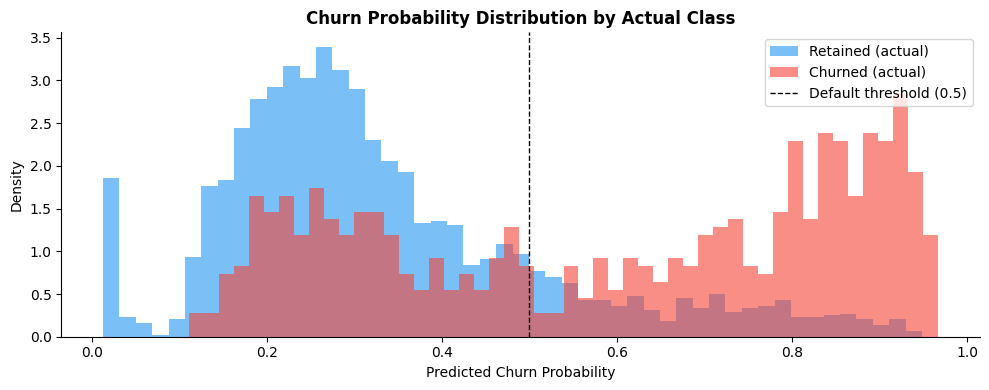

In [135]:
# Probability distribution of churn predictions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob_best[y_val == 0], bins=50, alpha=0.6, label='Retained (actual)', color='#2196F3', density=True)
ax.hist(y_prob_best[y_val == 1], bins=50, alpha=0.6, label='Churned (actual)', color='#F44336', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title('Churn Probability Distribution by Actual Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [146]:
# Cross-validation final check using Tomek Links on full training data
X_full_proc = preprocessor.transform(X_train_full)
X_full_res_tl, y_full_res_tl = tl.fit_resample(X_full_proc, y_train_full)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_model, X_full_res_tl, y_full_res_tl,
                             cv=cv,
                             scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV ROC-AUC (full Tomek-resampled data): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC (full Tomek-resampled data): 0.7773 ± 0.0093


## 12. Retrain on Full Data & Generate Test Predictions

In [147]:
# Retrain best model on ALL available training data (processed + SMOTE)
final_model = lgb.LGBMClassifier(**rscv.best_params_,
                                   class_weight='balanced',
                                   random_state=SEED,
                                   n_jobs=-1,
                                   verbose=-1)
final_model.fit(X_full_res, y_full_res)

# Predict on test set
test_probs  = final_model.predict_proba(X_test_proc)[:, 1]
test_labels = final_model.predict(X_test_proc)

submission = pd.DataFrame({
    'customer_id'     : test_feat['customer_id'],
    'predicted_churn' : test_labels
})

submission.to_csv(r"C:\Users\hravic02\OneDrive - dentsu\Desktop\Documents\AI Proficient - Machine Learning\Capstone Project\ml_churn_data_dentsu\churn_predictions.csv", index=False)
print('Predictions saved to churn_predictions.csv')
display(submission.head(10))

Predictions saved to churn_predictions.csv


,customer_id,predicted_churn
0,CUST008425,0
1,CUST018685,0
2,CUST014204,0
3,CUST018747,0
4,CUST010805,0
5,CUST009022,0
6,CUST007853,0
7,CUST007815,1
8,CUST017733,1
9,CUST002398,0


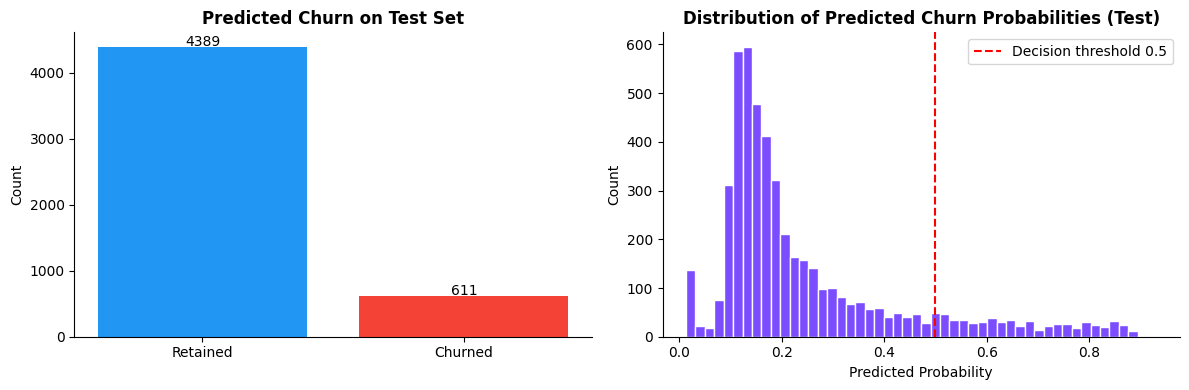


Predicted churn rate on test set: 12.22%


In [149]:
# Final prediction summary
pred_summary = submission['predicted_churn'].value_counts().reindex([0, 1], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Retained', 'Churned'], pred_summary[[0, 1]].values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Predicted Churn on Test Set', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(pred_summary[[0, 1]].values):
    axes[0].text(i, v + 20, str(v), ha='center')

axes[1].hist(test_probs, bins=50, color='#7C4DFF', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold 0.5')
axes[1].set_title('Distribution of Predicted Churn Probabilities (Test)', fontweight='bold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nPredicted churn rate on test set: {test_labels.mean() * 100:.2f}%')

## Final Business Summary

### Q&A

- **Who:** Customers with the highest predicted churn probability should be prioritized, subject to campaign capacity and customer-care policy.
- **What:** Recency, purchase activity, spend, engagement, support experience, contract, and loyalty signals provide the predictive context.
- **Where:** KMeans segments and segment-level churn rates identify groups where retention investment may have the greatest opportunity.
- **When:** Intervene before the next expected lapse in activity, using risk scores together with recency and lifecycle features.
- **Why:** LightGBM provides a strong fit for nonlinear interactions in mixed customer tables while remaining computationally practical.
- **How:** Convert risk scores into action bands, run controlled retention experiments, and measure incremental retention and economic value.

### Data Analysis Key Findings

- The training data contains approximately 21.3% churned customers, so minority-class metrics are more informative than accuracy alone.
- The current tuned LightGBM workflow reports validation ROC-AUC of 0.7745, average precision of 0.5849, churn recall of 0.60, and churn F1-score of 0.5479.
- The generated test prediction file contains one prediction per customer and is written to `outputs/churn_predictions.csv`.

### Insights or Next Steps

- Re-estimate performance with fold-safe preprocessing, clustering, and resampling before using the reported metrics as production estimates.
- Select the operating threshold using intervention capacity and the relative cost of missed churn versus unnecessary outreach, then validate through an A/B or holdout campaign.
